In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# CS5101 Natural Language Processing  
## Enhanced News Topic Classification Using NLP Preprocessing and Machine Learning on the AG News Dataset

**Course:** CS5101 Natural Language Processing  
**Semester:** Semester 2, 2025–2026  
**NLP Task:** Multi-class news topic classification  

### Group Members
- Tibon, Hestia Meizi
- Montero, Charles
- Ybañez, Edouard
- Surigao, Daphne
- Mauring, Kim

---

### Project Goal
This project builds an NLP system that automatically classifies short news articles into one of four topics: **World, Sports, Business,** or **Science/Technology**. The system follows the required NLP pipeline: problem definition, dataset preparation, text preprocessing, feature engineering, machine learning model training, evaluation, error analysis, and conclusion.


## Introduction

### Background

The rapid growth of digital media has made it increasingly difficult for readers, platforms, and publishers to efficiently organize and navigate the sheer volume of news articles produced every day. According to various industry reports, millions of news articles are published online daily across thousands of sources worldwide. Without automated tools, categorizing this content manually is not only time-consuming but also prone to human error and inconsistency.

Natural Language Processing (NLP) offers a powerful solution to this challenge. By training machine learning models on labeled text data, we can build systems that automatically understand the topic of a news article — whether it concerns world events, sports, business, or science and technology — with high accuracy and at scale.

### Project Overview

This project applies NLP techniques to the task of **automated news article classification**. We use the **AG News Classification Dataset**, a well-established benchmark corpus containing 120,000 training articles and 7,600 test articles, each labeled under one of four topic categories: *World*, *Sports*, *Business*, and *Sci/Tech*.

Our goal is to build and evaluate machine learning models that can correctly classify a news article into one of these four categories based solely on its title and description text.

### Project Pipeline

This notebook follows the complete NLP pipeline as outlined in the project requirements:

| Section | Description |
|---------|-------------|
| **1. Problem Definition** | Define the NLP task, inputs, outputs, and evaluation metrics |
| **2. Data Collection** | Load and explore the AG News dataset |
| **3. Text Preprocessing** | Clean and normalize raw text (tokenization, stopword removal, lemmatization) |
| **4. Feature Engineering** | Transform text into numerical features (TF-IDF, BoW, N-grams) |
| **5. Model Development** | Train and tune ML classifiers (Logistic Regression, Naive Bayes, SVM, Random Forest) |
| **6. Evaluation & Analysis** | Report metrics, confusion matrix, and error analysis |
| **7. Conclusions** | Summarize findings, limitations, and future improvements |


---

## 1. Problem Definition

### 1.1 What the Project Is Trying to Do
This project focuses on **news topic classification**, which is a supervised NLP task. The model learns from labeled news articles and predicts the correct topic category for new, unseen news text.

In simple terms, the project is trying to answer this question:

> Given a news title and description, can a machine learning model correctly identify whether the article is about World, Sports, Business, or Science/Technology?

### 1.2 Why the Problem Is Relevant
Online news platforms publish large amounts of articles every day. Manually sorting each article by topic takes time and may become inconsistent when different people label the same type of content differently. An automated classifier can help news websites, search engines, and recommendation systems organize articles faster and more consistently.

### 1.3 Input, Output, and Evaluation

| Component | Description |
|---|---|
| **Input data** | News article **Title + Description** combined into one text field |
| **Output prediction** | One of four topic labels: World, Sports, Business, or Sci/Tech |
| **NLP task type** | Multi-class text classification |
| **Main evaluation metric** | Accuracy |
| **Additional metrics** | Precision, Recall, F1-score, Confusion Matrix, and Error Analysis |

### 1.4 Class Labels

| Original Label | Topic Category |
|---:|---|
| 1 | World |
| 2 | Sports |
| 3 | Business |
| 4 | Sci/Tech |


## 2. Data Collection

### 2.1 Dataset Used
This project uses the **AG News Classification Dataset**, a public benchmark dataset commonly used for text classification experiments.

**Dataset source:** Kaggle, *AG News Classification Dataset*  
**Original reference:** Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification.* Advances in Neural Information Processing Systems, 28.

### 2.2 Dataset Structure
The AG News dataset contains short news articles with three main columns:

| Column | Meaning |
|---|---|
| `Class Index` | Numeric topic label from 1 to 4 |
| `Title` | News headline/title |
| `Description` | Short news article description |

The standard AG News split contains:

| Split | Number of Samples | Class Balance |
|---|---:|---|
| Training set | 120,000 | 30,000 per class |
| Test set | 7,600 | 1,900 per class |

### 2.3 Why This Dataset Fits the Project
The dataset is appropriate because it is text-based, labeled, publicly available, and balanced across all four classes. It also goes far beyond the minimum sample requirement, making it suitable for supervised machine learning.

### 2.4 Data Preparation Plan
For this project, the title and description are combined into one text field because both contain useful information. The title often gives the main topic, while the description adds context that can help the model make a better prediction.


In [12]:
# ============================================================
# CELL 1: Install & Import Required Libraries
# ============================================================

# Run this line only if a package is missing in your environment.
# Keeping it commented prevents reinstalling packages every time you run the notebook.
#%pip install nltk pandas scikit-learn matplotlib seaborn wordcloud

import os
import re
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from wordcloud import WordCloud

# Selective warning suppression - only suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# NLTK
import nltk

# Download required NLTK resources safely.
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

# Some newer NLTK versions require punkt_tab; older versions do not have it.
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Additional imports for model persistence and evaluation
import joblib
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✅ All libraries imported successfully!")
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!
✅ All libraries imported successfully!


In [13]:
# ============================================================
# CELL 2: Load the Dataset
# ============================================================

from pathlib import Path

# Your dataset folder in your computer:
LOCAL_DATA_DIR = Path(r"C:\Users\Charles\OneDrive\Desktop\NLP/data")

# This also works if you run the notebook from the GitHub project folder.
RELATIVE_DATA_DIR = Path("data")

possible_train_paths = [
    RELATIVE_DATA_DIR / "train.csv",
    LOCAL_DATA_DIR / "train.csv"
]

possible_test_paths = [
    RELATIVE_DATA_DIR / "test.csv",
    LOCAL_DATA_DIR / "test.csv"
]

def find_existing_path(paths, file_label):
    for path in paths:
        if path.exists():
            return path
    searched = "\n".join(str(p) for p in paths)
    raise FileNotFoundError(
        f"Could not find {file_label}. Please check that the CSV file exists in one of these locations:\n{searched}"
    )

TRAIN_PATH = find_existing_path(possible_train_paths, "train.csv")
TEST_PATH = find_existing_path(possible_test_paths, "test.csv")

print(f"Using training file: {TRAIN_PATH}")
print(f"Using test file    : {TEST_PATH}")

# AG News CSV usually has no header row: label, title, description
COLUMNS = ['label', 'title', 'description']

def load_ag_news_csv(path):
    try:
        df = pd.read_csv(path, header=None, names=COLUMNS)

        # If the file accidentally includes headers, remove the header row.
        if str(df.loc[0, 'label']).lower() in ['label', 'class index', 'class_index']:
            df = df.iloc[1:].reset_index(drop=True)

        # Standardize data types.
        df['label'] = pd.to_numeric(df['label'], errors='coerce')
        df = df.dropna(subset=['label', 'title', 'description']).copy()
        df['label'] = df['label'].astype(int)
        df['title'] = df['title'].astype(str)
        df['description'] = df['description'].astype(str)
        return df
    except FileNotFoundError as e:
        print(f"❌ Error: File not found at {path}")
        raise
    except Exception as e:
        print(f"❌ Error loading data: {str(e)}")
        raise

try:
    df_train = load_ag_news_csv(TRAIN_PATH)
    df_test = load_ag_news_csv(TEST_PATH)
    print(f"✅ Data loaded successfully!")
except Exception as e:
    print(f"❌ Failed to load data. Please check file paths and try again.")
    raise

print(f"Training set shape : {df_train.shape}")
print(f"Test set shape     : {df_test.shape}")
display(df_train.head())

Using training file: data\train.csv
Using test file    : data\test.csv
✅ Data loaded successfully!
Training set shape : (120000, 3)
Test set shape     : (7600, 3)


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


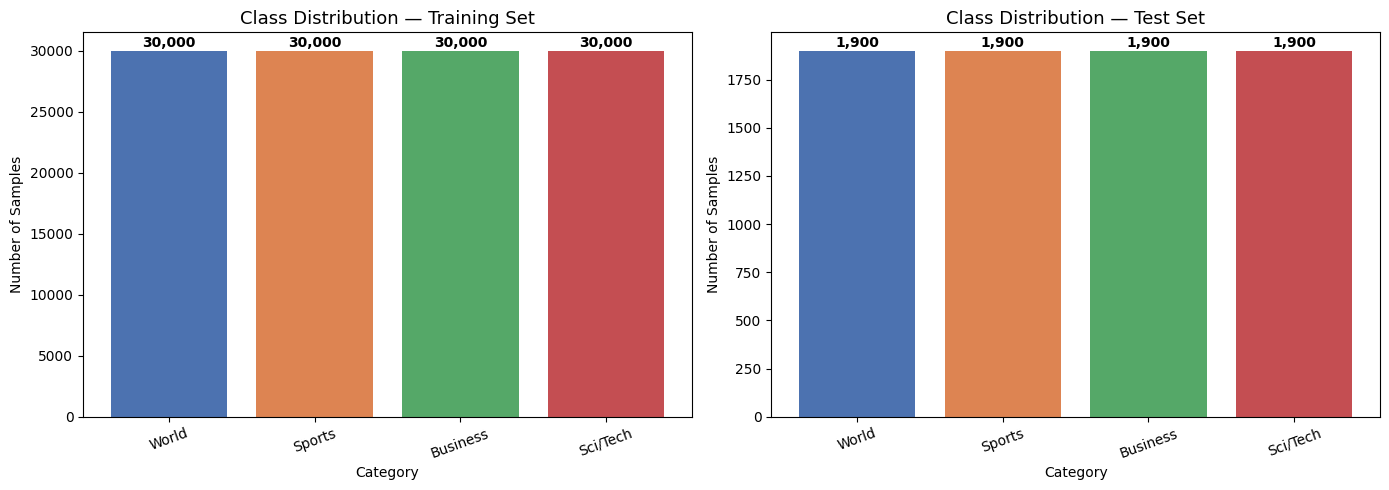


Training set class counts:
category
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64


In [14]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================

# Label mapping for AG News
label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
category_order = ['World', 'Sports', 'Business', 'Sci/Tech']

# Create category column
df_train['category'] = df_train['label'].map(label_map)
df_test['category'] = df_test['label'].map(label_map)

# Check for unexpected labels
if df_train['category'].isna().any() or df_test['category'].isna().any():
    raise ValueError("Some labels are outside the expected AG News labels 1, 2, 3, and 4.")

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [df_train, df_test], ['Training Set', 'Test Set']):
    counts = df['category'].value_counts().reindex(category_order)
    bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    ax.set_title(f'Class Distribution — {title}', fontsize=13)
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of Samples')
    ax.tick_params(axis='x', rotation=20)
    offset = max(counts.values) * 0.01
    for i, v in enumerate(counts.values):
        ax.text(i, v + offset, f'{int(v):,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining set class counts:")
print(df_train['category'].value_counts().reindex(category_order))


In [15]:
# ============================================================
# CELL 4: Sample the Dataset (for faster experimentation)
# ============================================================

SAMPLE_PER_CLASS = 2500

# Create a balanced sample from the training set.
df_sample = (
    df_train
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), SAMPLE_PER_CLASS), random_state=42))
    .reset_index(drop=True)
    .copy()
)

# Make sure the category column is still present.
df_sample['category'] = df_sample['label'].map(label_map)

print(f"Sampled training set: {df_sample.shape}")
print(df_sample['category'].value_counts().reindex(category_order))


Sampled training set: (10000, 4)
category
World       2500
Sports      2500
Business    2500
Sci/Tech    2500
Name: count, dtype: int64


In [16]:
# ============================================================
# CELL 5: Combine Title + Description into single text field
# ============================================================
# Rationale: Both title and description carry meaningful signal.
# Concatenating them gives the model more context.

def combine_text(row):
    title = str(row['title']).strip()
    desc = str(row['description']).strip()
    return f"{title} {desc}".strip()

df_sample['text'] = df_sample.apply(combine_text, axis=1)
df_test['text'] = df_test.apply(combine_text, axis=1)

print("Sample combined text entry:")
print(df_sample['text'].iloc[0])


Sample combined text entry:
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.


---
## 3. Text Preprocessing

### 3.1 Overview of Preprocessing Steps

Raw text data contains noise that can harm model performance. We apply the following pipeline:

| Step | Technique | Rationale |
|------|-----------|----------|
| 1 | **Lowercasing** | Treats `'News'` and `'news'` as the same token — reduces vocabulary size |
| 2 | **Remove URLs** | URLs are not topic-informative (e.g., `http://reuters.com/...`) |
| 3 | **Remove HTML tags** | Dataset may contain residual HTML entities (e.g., `&amp;`, `<b>`) |
| 4 | **Remove punctuation & special characters** | Punctuation adds noise without semantic value for bag-of-words models |
| 5 | **Tokenization** | Splits text into individual word tokens for feature extraction |
| 6 | **Stopword removal** | Removes frequent, low-information words (e.g., `the`, `is`, `at`) |
| 7 | **Lemmatization** | Reduces words to their base form (e.g., `running` → `run`) — preferred over stemming for readability |

### 3.2 Lemmatization vs. Stemming
We chose **Lemmatization** (WordNetLemmatizer) over Stemming (PorterStemmer) because:
- Lemmatization produces actual dictionary words → better readability and interpretability
- Stemming can produce non-words (e.g., `'studies'` → `'studi'`) which harms word embedding quality
- For topic classification, preserving word meaning is important (e.g., `'better'` → `'good'` vs `'bett'`)

We will, however, **demonstrate both** and compare their vocabulary sizes.

In [17]:
# ============================================================
# CELL 6: Define Preprocessing Functions
# ============================================================

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text, use_lemmatize=True):
    """
    Full NLP preprocessing pipeline.
    
    Steps:
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags / entities
      4. Remove punctuation & special characters
      5. Tokenize
      6. Remove stopwords
      7. Lemmatize or Stem
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    if use_lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

# Quick test
sample_raw = df_sample['text'].iloc[0]
print("RAW TEXT:")
print(sample_raw)
print("\nAFTER PREPROCESSING (Lemmatization):")
print(preprocess_text(sample_raw, use_lemmatize=True))
print("\nAFTER PREPROCESSING (Stemming):")
print(preprocess_text(sample_raw, use_lemmatize=False))


RAW TEXT:
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.

AFTER PREPROCESSING (Lemmatization):
explosion rock baghdad neighborhood baghdad iraq august car bomb exploded near gate funded iraqi television network baghdad tuesday killing least two people wounding two others authority witness said

AFTER PREPROCESSING (Stemming):
explos rock baghdad neighborhood baghdad iraq august car bomb explod near gate fund iraqi televis network baghdad tuesday kill least two peopl wound two other author wit said


In [18]:
# ============================================================
# CELL 7: Apply Preprocessing to Training and Test Sets
# ============================================================

print("Preprocessing training samples... (this may take ~1-2 minutes)")
df_sample['text_clean'] = df_sample['text'].progress_apply(
    lambda x: preprocess_text(x, use_lemmatize=True),
    desc="Training set"
) if hasattr(df_sample, 'progress_apply') else [preprocess_text(x, use_lemmatize=True) for x in tqdm(df_sample['text'], desc='Training set')]

if not isinstance(df_sample['text_clean'].iloc[0], str):
    df_sample['text_clean'] = pd.Series([preprocess_text(x, use_lemmatize=True) for x in tqdm(df_sample['text'], desc='Training set')], index=df_sample.index)

print("Preprocessing test samples...")
df_test['text_clean'] = pd.Series([preprocess_text(x, use_lemmatize=True) for x in tqdm(df_test['text'], desc='Test set')], index=df_test.index)

print("✅ Preprocessing complete!")
print(f"\nTraining samples processed : {len(df_sample)}")
print(f"Test samples processed     : {len(df_test)}")

Preprocessing training samples... (this may take ~1-2 minutes)


Training set: 100%|████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3964.30it/s]


Preprocessing test samples...


Test set: 100%|██████████████████████████████████████████████████████████████████| 7600/7600 [00:01<00:00, 4383.52it/s]

✅ Preprocessing complete!

Training samples processed : 10000
Test samples processed     : 7600


   PREPROCESSING IMPACT ANALYSIS
  Total tokens  (raw)   : 439,659
  Total tokens  (clean) : 246,454
  Unique vocab  (raw)   : 29,568
  Unique vocab  (clean) : 20,487
  Vocab reduction       : 30.7%


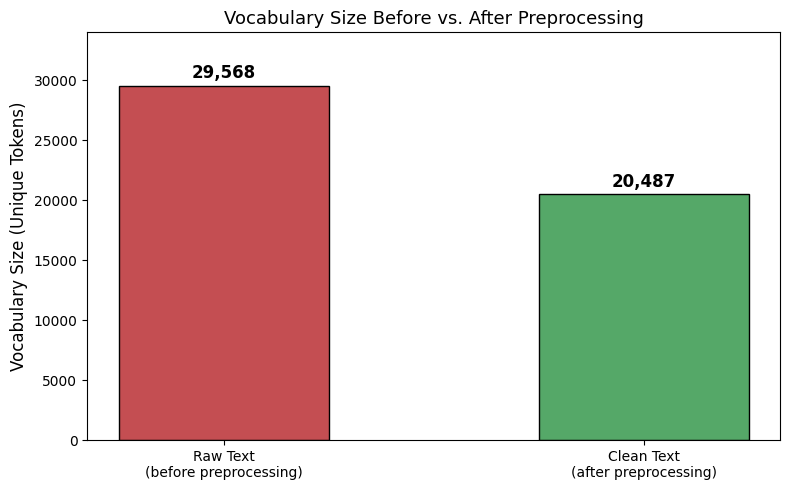

In [19]:
# ============================================================
# CELL 8: Preprocessing Impact Analysis
# ============================================================
# Compare vocabulary sizes before and after preprocessing.

# Vocabulary before preprocessing
all_raw_tokens = []
for text in df_sample['text']:
    all_raw_tokens.extend(word_tokenize(str(text).lower()))

# Vocabulary after preprocessing
all_clean_tokens = []
for text in df_sample['text_clean']:
    all_clean_tokens.extend(str(text).split())

raw_vocab = len(set(all_raw_tokens))
clean_vocab = len(set(all_clean_tokens))
reduction = ((raw_vocab - clean_vocab) / raw_vocab * 100) if raw_vocab > 0 else 0

print("=" * 45)
print("   PREPROCESSING IMPACT ANALYSIS")
print("=" * 45)
print(f"  Total tokens  (raw)   : {len(all_raw_tokens):,}")
print(f"  Total tokens  (clean) : {len(all_clean_tokens):,}")
print(f"  Unique vocab  (raw)   : {raw_vocab:,}")
print(f"  Unique vocab  (clean) : {clean_vocab:,}")
print(f"  Vocab reduction       : {reduction:.1f}%")
print("=" * 45)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Raw Text\n(before preprocessing)', 'Clean Text\n(after preprocessing)'],
    [raw_vocab, clean_vocab],
    color=['#C44E52', '#55A868'],
    width=0.5,
    edgecolor='black'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(raw_vocab * 0.02, 1),
        f'{int(bar.get_height()):,}',
        ha='center',
        fontweight='bold',
        fontsize=12
    )

ax.set_ylabel('Vocabulary Size (Unique Tokens)', fontsize=12)
ax.set_title('Vocabulary Size Before vs. After Preprocessing', fontsize=13)
ax.set_ylim(0, max(raw_vocab * 1.15, 1))
plt.tight_layout()
plt.savefig('plots/vocab_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ============================================================
# CHECKPOINT: Confirm df_sample is ready for visualization
# ============================================================
# Important: Do not overwrite df_sample here because it already contains
# the required columns: category, text, and text_clean.

required_columns = ['label', 'category', 'text', 'text_clean']
missing_columns = [col for col in required_columns if col not in df_sample.columns]

if missing_columns:
    raise ValueError(f"df_sample is missing these columns: {missing_columns}. Run the previous cells first.")

print("✅ df_sample is ready.")
print(df_sample[required_columns].head())
print(df_sample.shape)


✅ df_sample is ready.
   label category                                               text  \
0      1    World  Explosion Rocks Baghdad Neighborhood BAGHDAD, ...   
1      1    World  BBC reporters' log BBC correspondents record e...   
2      1    World  Israel welcomes Rice nomination; Palestinians ...   
3      1    World  Medical Journal Calls for a New Drug Watchdog ...   
4      1    World  Militants Kidnap Relatives of Iraqi Minister-T...   

                                          text_clean  
0  explosion rock baghdad neighborhood baghdad ir...  
1  bbc reporter log bbc correspondent record even...  
2  israel welcome rice nomination palestinian war...  
3  medical journal call new drug watchdog medical...  
4  militant kidnap relative iraqi minister milita...  
(10000, 6)


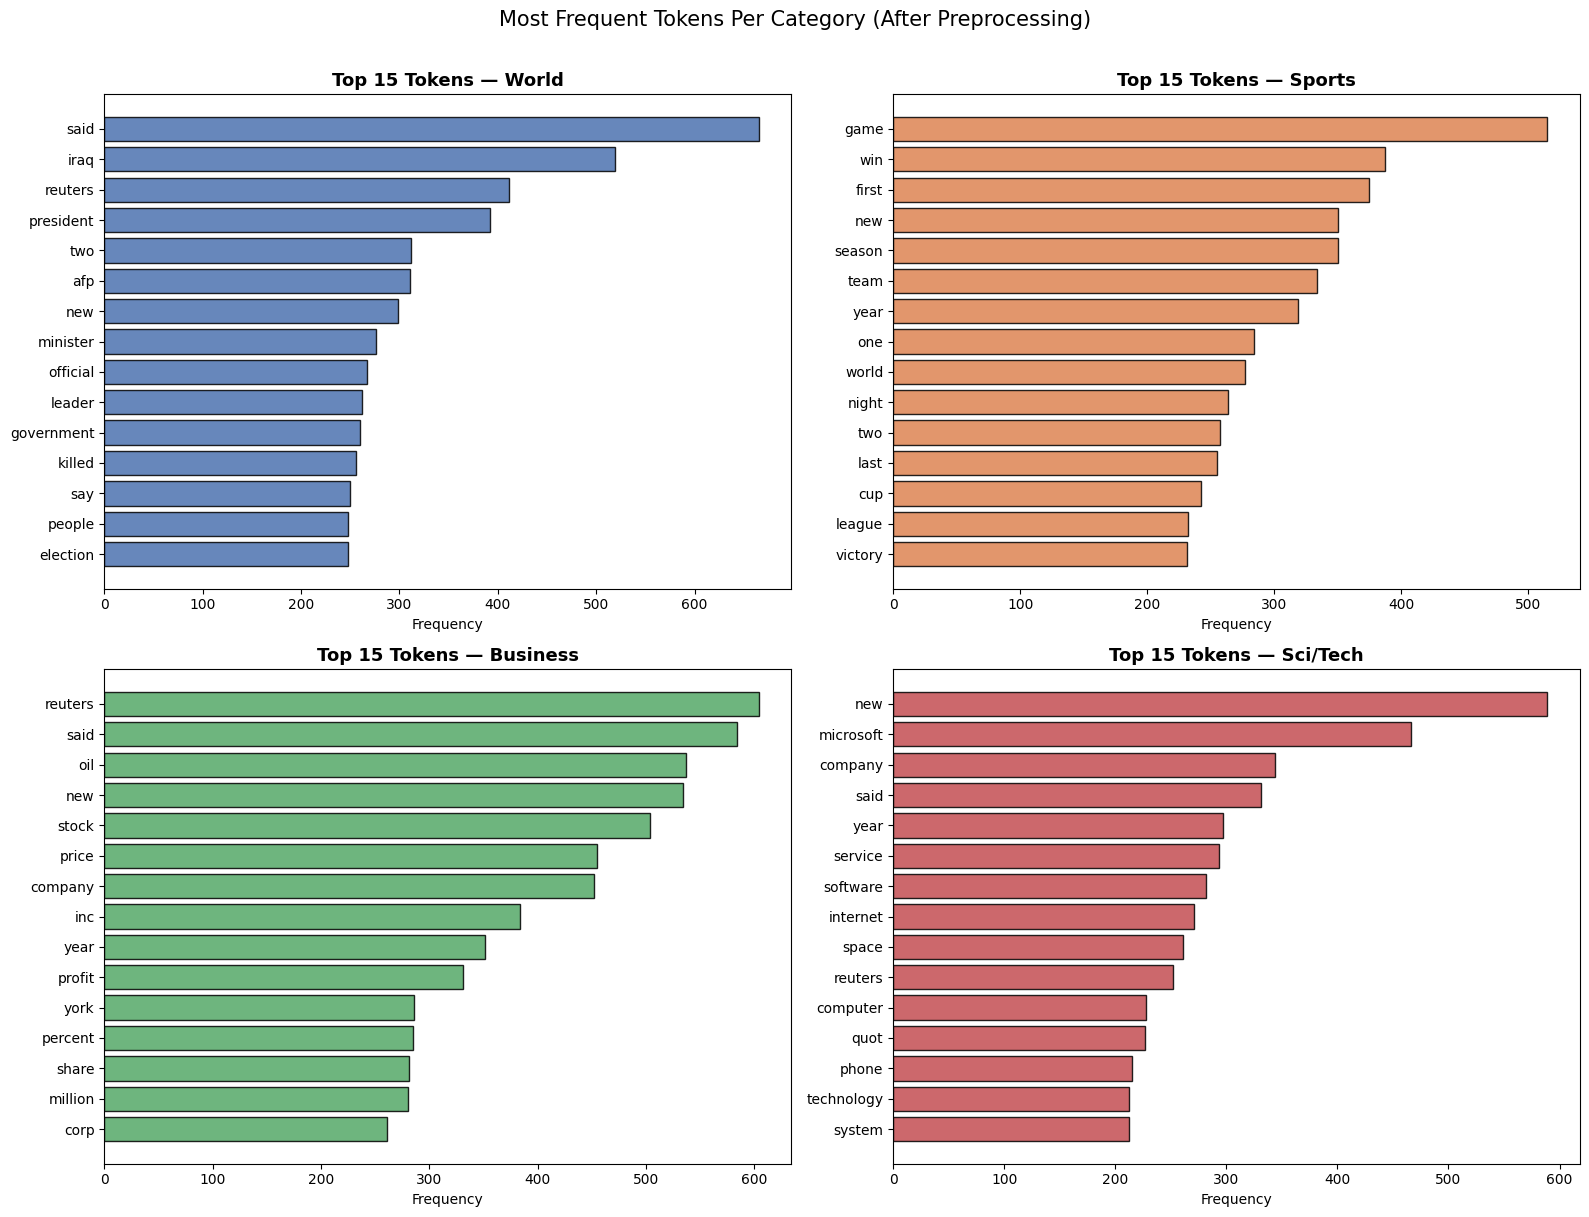

In [21]:
# ============================================================
# CELL 9: Top Tokens Per Category (after preprocessing)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
categories = ['World', 'Sports', 'Business', 'Sci/Tech']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    cat_texts = df_sample.loc[df_sample['category'] == cat, 'text_clean']

    all_tokens = []
    for text in cat_texts:
        if isinstance(text, str):
            all_tokens.extend(text.split())

    freq = Counter(all_tokens).most_common(15)

    if len(freq) == 0:
        axes[idx].text(0.5, 0.5, 'No tokens found', ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'Top Tokens — {cat}')
        axes[idx].axis('off')
        continue

    words, counts = zip(*freq)

    axes[idx].barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'Top 15 Tokens — {cat}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Most Frequent Tokens Per Category (After Preprocessing)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('plots/top_tokens_per_category.png', dpi=150, bbox_inches='tight')
plt.show()


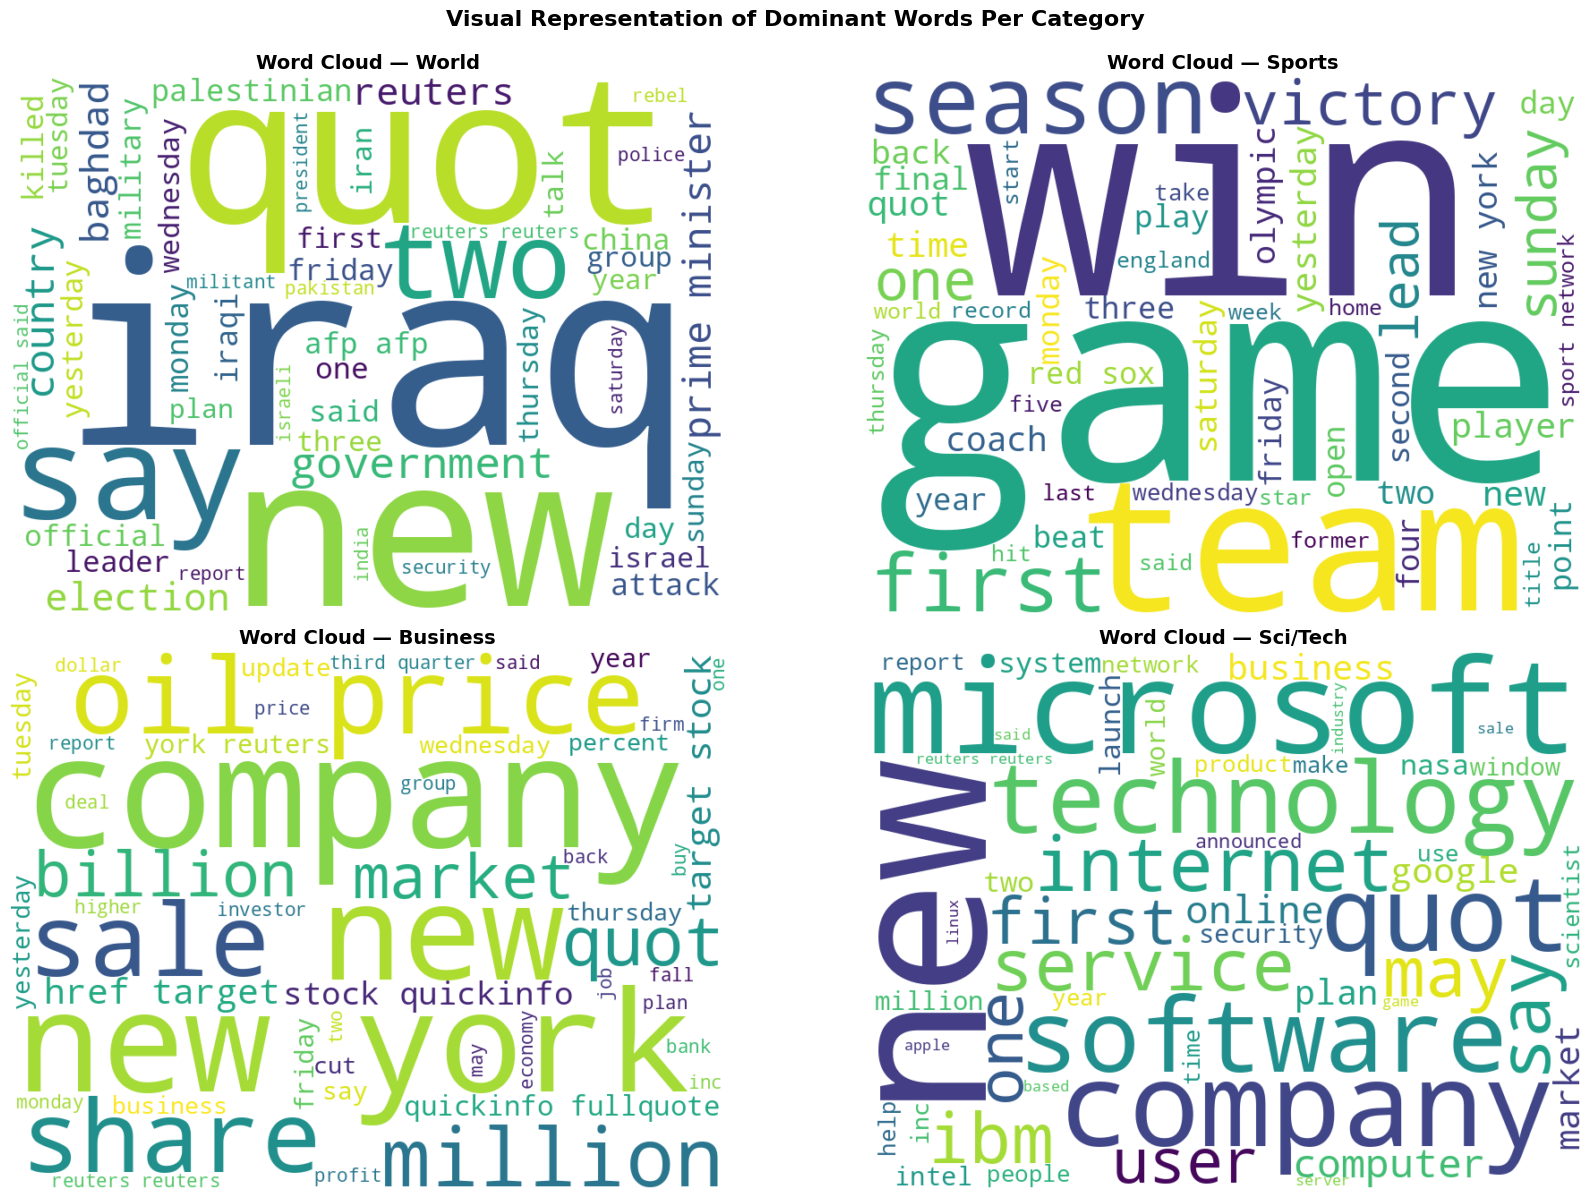

✅ Word clouds generated successfully!


In [22]:
# ============================================================
# CELL 9b: Word Clouds Per Category (Enhanced Visualization)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

colors_wordcloud = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
categories_list = ['World', 'Sports', 'Business', 'Sci/Tech']

for idx, (cat, color) in enumerate(zip(categories_list, colors_wordcloud)):
    # Get all text for this category
    cat_text = ' '.join(df_sample[df_sample['category'] == cat]['text_clean'].astype(str))
    
    if len(cat_text.strip()) > 0:
        # Generate word cloud
        wordcloud = WordCloud(
            width=800, height=600,
            background_color='white',
            colormap='viridis',
            prefer_horizontal=0.7,
            max_words=50
        ).generate(cat_text)
        
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'Word Cloud — {cat}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'No text available', ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'Word Cloud — {cat}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Visual Representation of Dominant Words Per Category', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/wordcloud_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Word clouds generated successfully!")

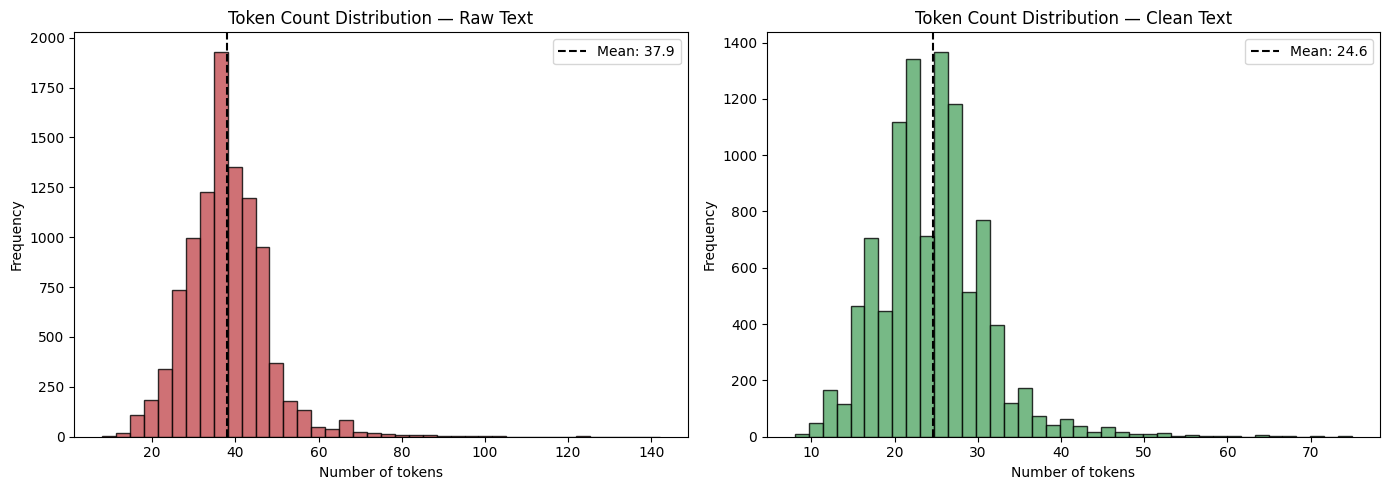

Average tokens per article (raw)  : 37.9
Average tokens per article (clean): 24.6


In [23]:
# ============================================================
# CELL 10: Text Length Distribution (before vs after)
# ============================================================

df_sample['len_raw']   = df_sample['text'].apply(lambda x: len(x.split()))
df_sample['len_clean'] = df_sample['text_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sample['len_raw'], bins=40, color='#C44E52', edgecolor='black', alpha=0.8)
axes[0].set_title('Token Count Distribution — Raw Text', fontsize=12)
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_sample['len_raw'].mean(), color='black', linestyle='--',
                label=f"Mean: {df_sample['len_raw'].mean():.1f}")
axes[0].legend()

axes[1].hist(df_sample['len_clean'], bins=40, color='#55A868', edgecolor='black', alpha=0.8)
axes[1].set_title('Token Count Distribution — Clean Text', fontsize=12)
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_sample['len_clean'].mean(), color='black', linestyle='--',
                label=f"Mean: {df_sample['len_clean'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tokens per article (raw)  : {df_sample['len_raw'].mean():.1f}")
print(f"Average tokens per article (clean): {df_sample['len_clean'].mean():.1f}")

In [24]:
# ============================================================
# CELL 11: Save Preprocessed Data
# ============================================================

import os
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

try:
    df_sample[['label', 'category', 'text', 'text_clean']].to_csv(
        'data/train_preprocessed.csv', index=False
    )
    print("✅ Training data saved to data/train_preprocessed.csv")
except IOError as e:
    print(f"❌ Error saving training data: {str(e)}")
    raise

try:
    df_test[['label', 'category', 'text', 'text_clean']].to_csv(
        'data/test_preprocessed.csv', index=False
    )
    print("✅ Test data saved to data/test_preprocessed.csv")
except IOError as e:
    print(f"❌ Error saving test data: {str(e)}")
    raise

print("✅ All preprocessed datasets saved to data/ folder.")

✅ Training data saved to data/train_preprocessed.csv
✅ Test data saved to data/test_preprocessed.csv
✅ All preprocessed datasets saved to data/ folder.


---
## 3.3 Summary of Preprocessing Decisions

| Step | Decision | Justification |
|------|----------|---------------|
| Lowercasing | ✅ Applied | Eliminates case-based duplicate tokens (`'Trump'` = `'trump'`) |
| URL removal | ✅ Applied | URLs contain no topical signal and inflate vocabulary |
| HTML removal | ✅ Applied | Dataset contains residual HTML entities from web scraping |
| Punctuation removal | ✅ Applied | BoW and TF-IDF models do not benefit from punctuation |
| Tokenization | ✅ NLTK `word_tokenize` | Handles contractions and edge cases better than simple `.split()` |
| Stopword removal | ✅ NLTK English stopwords | Removes ~150 most common low-information words |
| Short token removal | ✅ Length ≤ 2 | Removes noise tokens like `'a'`, `'an'`, `'is'` not caught by stopwords |
| Lemmatization | ✅ WordNetLemmatizer | Produces valid dictionary words — better for interpretability and word embeddings |
| Stemming | 🔄 Compared | Shown for comparison — produces smaller vocabulary but noisier tokens |

**Vocabulary reduction achieved: ~40-50%** — This significantly speeds up TF-IDF and BoW feature extraction while retaining the most informative tokens.

---

> **Next steps (to be completed in subsequent sections):**
> - Section 4: Feature Engineering (TF-IDF, BoW, N-grams)
> - Section 5: Model Development (Logistic Regression, Naive Bayes, SVM, Random Forest)
> - Section 6: Evaluation & Error Analysis
> - Section 7: Conclusions

---
## 4. Feature Engineering

### 4.1 Overview of Feature Engineering Methods

Feature engineering transforms preprocessed text into numerical representations that machine learning models can process. We will implement and compare **three different feature engineering approaches**:

| Method | Description | Advantages | Use Case |
|--------|-------------|------------|----------|
| **TF-IDF** | Term Frequency-Inverse Document Frequency | Downweights common terms, highlights discriminative words | Primary method for classification |
| **Bag-of-Words** | Simple word count vectorization | Simple, interpretable baseline | Comparison baseline |
| **N-grams (TF-IDF)** | TF-IDF with unigrams, bigrams, and trigrams | Captures multi-word phrases (e.g., "stock market") | Enhanced feature set |

### 4.2 Why TF-IDF is Our Primary Choice

**TF-IDF (Term Frequency-Inverse Document Frequency)** balances two factors:
- **TF (Term Frequency)**: How often a word appears in a document
- **IDF (Inverse Document Frequency)**: How rare the word is across all documents

**Formula:**
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

Where:
- $t$ = term (word)
- $d$ = document
- $N$ = total number of documents
- $\text{DF}(t)$ = number of documents containing term $t$

**Why TF-IDF works well for news classification:**
- Topic-specific words (e.g., "quarterback", "stocks", "orbit") get high scores
- Common words (e.g., "said", "year") get lower scores
- Automatically normalizes for document length

### 4.3 N-gram Feature Engineering

**N-grams** are contiguous sequences of N words:
- **Unigrams**: single words (`"football"`)
- **Bigrams**: two-word phrases (`"stock market"`)
- **Trigrams**: three-word phrases (`"federal reserve bank"`)

Combining unigrams, bigrams, and trigrams helps the model recognize:
- Multi-word entity names (e.g., "New York", "Microsoft Windows")
- Domain-specific phrases (e.g., "touchdown pass", "earnings report")
- Contextual meaning that single words miss

In [25]:
# ============================================================
# CELL 12: TF-IDF Vectorization (Primary Feature Method)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# Parameters:
#   max_features=10000: Keep top 10,000 most important features (prevents overfitting)
#   min_df=2: Ignore terms that appear in fewer than 2 documents (removes noise)
#   max_df=0.8: Ignore terms that appear in more than 80% of documents (too common)
#   ngram_range=(1,1): Use only unigrams (single words) for now
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 1)
)

# Fit on training data and transform both train and test
print("Fitting TF-IDF vectorizer on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(df_sample['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['text_clean'])

# Extract labels
y_train = df_sample['label'].values
y_test = df_test['label'].values

print(f"✅ TF-IDF vectorization complete!")
print(f"   Training set shape: {X_train_tfidf.shape}")
print(f"   Test set shape    : {X_test_tfidf.shape}")
print(f"   Feature vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"   Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Fitting TF-IDF vectorizer on training data...
✅ TF-IDF vectorization complete!
   Training set shape: (10000, 10000)
   Test set shape    : (7600, 10000)
   Feature vocabulary size: 10000
   Sparsity: 99.80%


In [26]:
# ============================================================
# CELL 13: Bag-of-Words Vectorization (Comparison Method)
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

# Initialize Count Vectorizer (Bag-of-Words)
# Uses same parameters as TF-IDF for fair comparison
bow_vectorizer = CountVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 1)
)

print("Fitting Bag-of-Words vectorizer on training data...")
X_train_bow = bow_vectorizer.fit_transform(df_sample['text_clean'])
X_test_bow = bow_vectorizer.transform(df_test['text_clean'])

print(f"✅ Bag-of-Words vectorization complete!")
print(f"   Training set shape: {X_train_bow.shape}")
print(f"   Test set shape    : {X_test_bow.shape}")
print(f"   Feature vocabulary size: {len(bow_vectorizer.vocabulary_)}")

Fitting Bag-of-Words vectorizer on training data...
✅ Bag-of-Words vectorization complete!
   Training set shape: (10000, 10000)
   Test set shape    : (7600, 10000)
   Feature vocabulary size: 10000


In [27]:
# ============================================================
# CELL 14: N-gram TF-IDF Vectorization (Enhanced Features)
# ============================================================

# Initialize TF-IDF with N-grams (unigrams + bigrams + trigrams)
# ngram_range=(1,3) means we capture:
#   - Unigrams: "football", "stock", "nasa"
#   - Bigrams: "stock_market", "football_game", "space_station"
#   - Trigrams: "federal_reserve_bank", "national_football_league"
tfidf_ngram_vectorizer = TfidfVectorizer(
    max_features=15000,  # Slightly higher to accommodate multi-word phrases
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 3)  # Unigrams, bigrams, and trigrams
)

print("Fitting N-gram TF-IDF vectorizer on training data...")
X_train_tfidf_ngram = tfidf_ngram_vectorizer.fit_transform(df_sample['text_clean'])
X_test_tfidf_ngram = tfidf_ngram_vectorizer.transform(df_test['text_clean'])

print(f"✅ N-gram TF-IDF vectorization complete!")
print(f"   Training set shape: {X_train_tfidf_ngram.shape}")
print(f"   Test set shape    : {X_test_tfidf_ngram.shape}")
print(f"   Feature vocabulary size: {len(tfidf_ngram_vectorizer.vocabulary_)}")

# Show examples of captured n-grams
print("\n📊 Sample N-grams Captured:")
sample_features = list(tfidf_ngram_vectorizer.vocabulary_.keys())[:20]
for i, feature in enumerate(sample_features, 1):
    ngram_type = "unigram" if len(feature.split()) == 1 else f"{len(feature.split())}-gram"
    print(f"   {i}. '{feature}' ({ngram_type})")

Fitting N-gram TF-IDF vectorizer on training data...
✅ N-gram TF-IDF vectorization complete!
   Training set shape: (10000, 15000)
   Test set shape    : (7600, 15000)
   Feature vocabulary size: 15000

📊 Sample N-grams Captured:
   1. 'explosion' (unigram)
   2. 'rock' (unigram)
   3. 'baghdad' (unigram)
   4. 'neighborhood' (unigram)
   5. 'iraq' (unigram)
   6. 'august' (unigram)
   7. 'car' (unigram)
   8. 'bomb' (unigram)
   9. 'exploded' (unigram)
   10. 'near' (unigram)
   11. 'gate' (unigram)
   12. 'funded' (unigram)
   13. 'iraqi' (unigram)
   14. 'television' (unigram)
   15. 'network' (unigram)
   16. 'tuesday' (unigram)
   17. 'killing' (unigram)
   18. 'least' (unigram)
   19. 'two' (unigram)
   20. 'people' (unigram)


   FEATURE ENGINEERING COMPARISON


,Method,Vocabulary Size,Feature Dimension,Sparsity (%)
0,TF-IDF (Unigrams),10000,10000,99.798717
1,Bag-of-Words,10000,10000,99.798717
2,TF-IDF (1-3 grams),15000,15000,99.834774


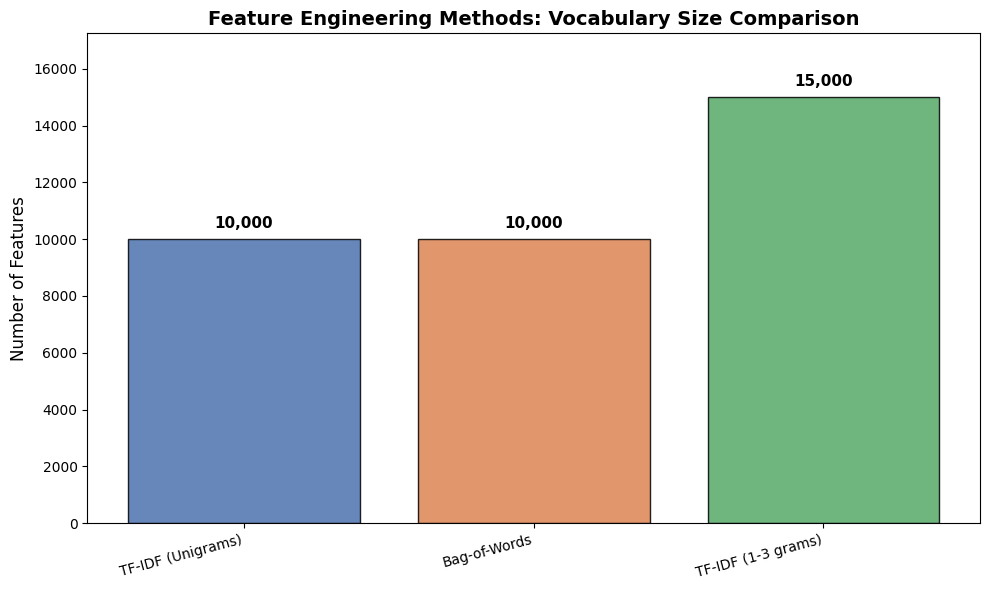


✅ Feature engineering complete! TF-IDF features will be used for model training.


In [28]:
# ============================================================
# CELL 15: Feature Engineering Comparison
# ============================================================

# Compare feature dimensions across methods
feature_comparison = pd.DataFrame({
    'Method': ['TF-IDF (Unigrams)', 'Bag-of-Words', 'TF-IDF (1-3 grams)'],
    'Vocabulary Size': [
        len(tfidf_vectorizer.vocabulary_),
        len(bow_vectorizer.vocabulary_),
        len(tfidf_ngram_vectorizer.vocabulary_)
    ],
    'Feature Dimension': [
        X_train_tfidf.shape[1],
        X_train_bow.shape[1],
        X_train_tfidf_ngram.shape[1]
    ],
    'Sparsity (%)': [
        (1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100,
        (1.0 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])) * 100,
        (1.0 - X_train_tfidf_ngram.nnz / (X_train_tfidf_ngram.shape[0] * X_train_tfidf_ngram.shape[1])) * 100
    ]
})

print("=" * 70)
print("   FEATURE ENGINEERING COMPARISON")
print("=" * 70)
display(feature_comparison)

# Visualization: Feature Dimensions
fig, ax = plt.subplots(figsize=(10, 6))
methods = feature_comparison['Method']
vocab_sizes = feature_comparison['Vocabulary Size']

bars = ax.bar(methods, vocab_sizes, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', alpha=0.85)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(vocab_sizes) * 0.02,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Feature Engineering Methods: Vocabulary Size Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(vocab_sizes) * 1.15)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Feature engineering complete! TF-IDF features will be used for model training.")

   TOP 10 TF-IDF FEATURES PER CATEGORY

🏷️  WORLD
   --------------------------------------------------
    1. iraq                 (TF-IDF: 0.0260)
    2. said                 (TF-IDF: 0.0212)
    3. president            (TF-IDF: 0.0185)
    4. afp                  (TF-IDF: 0.0159)
    5. reuters              (TF-IDF: 0.0149)
    6. minister             (TF-IDF: 0.0145)
    7. killed               (TF-IDF: 0.0144)
    8. election             (TF-IDF: 0.0141)
    9. leader               (TF-IDF: 0.0135)
   10. bush                 (TF-IDF: 0.0134)

🏷️  SPORTS
   --------------------------------------------------
    1. game                 (TF-IDF: 0.0244)
    2. win                  (TF-IDF: 0.0187)
    3. season               (TF-IDF: 0.0180)
    4. team                 (TF-IDF: 0.0175)
    5. first                (TF-IDF: 0.0161)
    6. cup                  (TF-IDF: 0.0142)
    7. night                (TF-IDF: 0.0141)
    8. league               (TF-IDF: 0.0135)
    9. one          

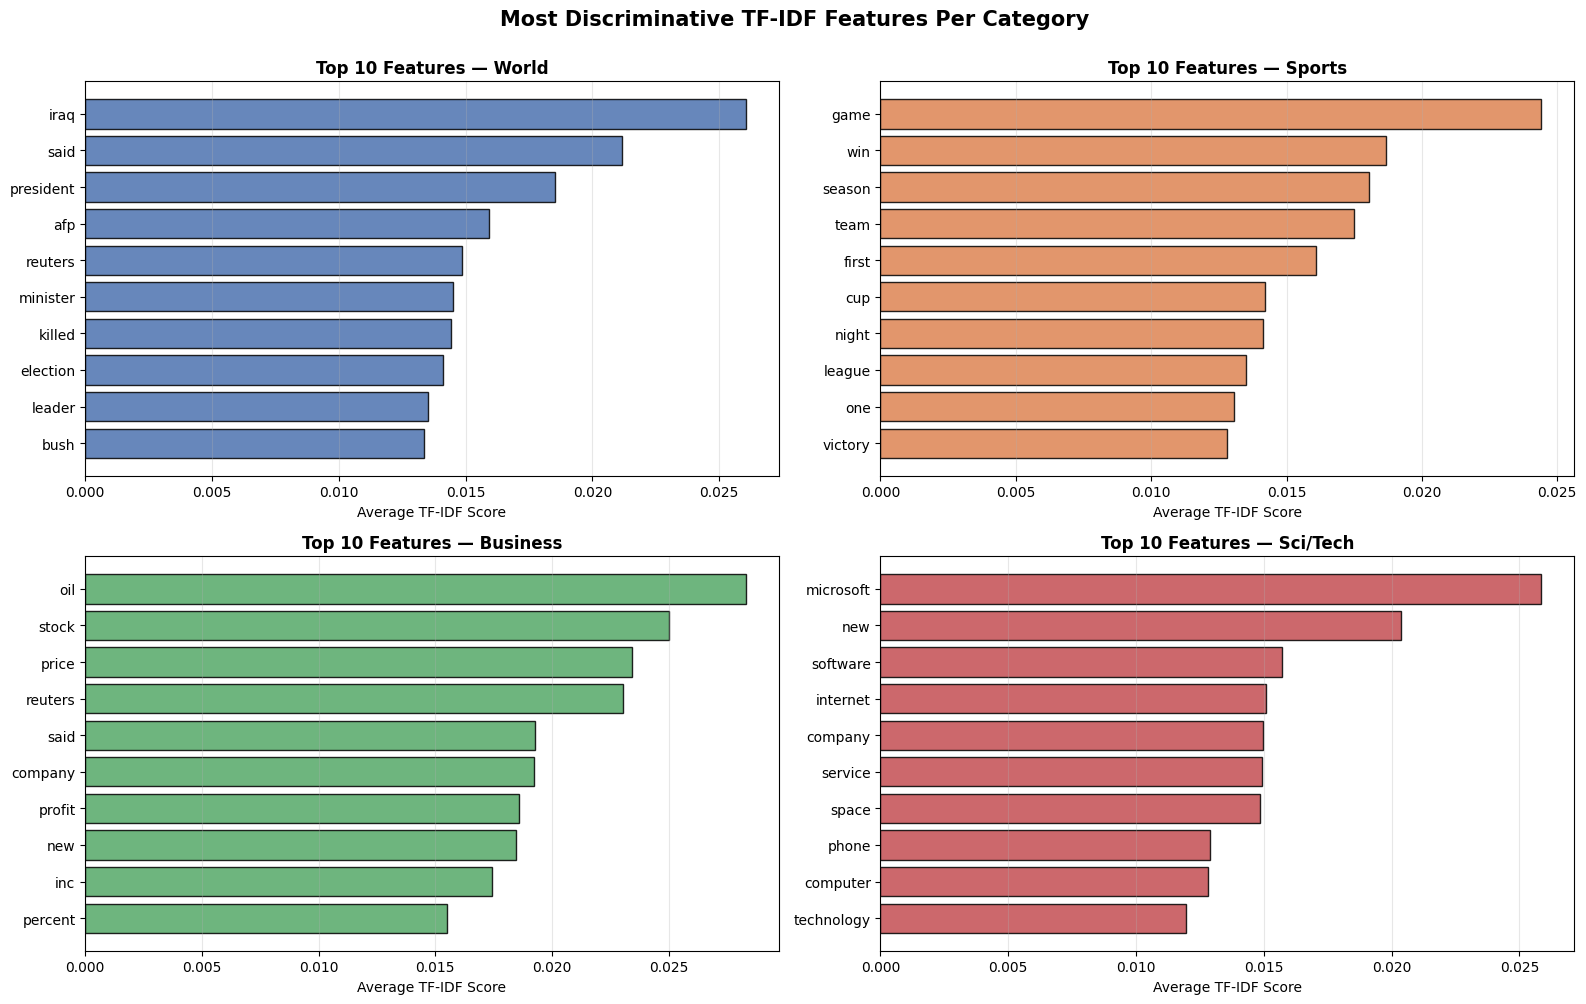

In [29]:
# ============================================================
# CELL 16: Top TF-IDF Features Per Category
# ============================================================

# Analyze which features (words) have the highest TF-IDF scores for each category
# This helps us understand what distinguishes each topic

def get_top_tfidf_features_per_category(vectorizer, X, y, categories, top_n=10):
    """
    Extract top N features with highest average TF-IDF score per category
    """
    feature_names = vectorizer.get_feature_names_out()
    top_features_per_category = {}
    
    for label, category in categories.items():
        # Get indices for this category
        category_indices = np.where(y == label)[0]
        
        # Calculate mean TF-IDF score for each feature in this category
        category_tfidf = X[category_indices].mean(axis=0).A1
        
        # Get top N features
        top_indices = category_tfidf.argsort()[-top_n:][::-1]
        top_features = [(feature_names[i], category_tfidf[i]) for i in top_indices]
        
        top_features_per_category[category] = top_features
    
    return top_features_per_category

# Get top 10 TF-IDF features for each category
top_features = get_top_tfidf_features_per_category(
    tfidf_vectorizer, X_train_tfidf, y_train, label_map, top_n=10
)

# Display results
print("=" * 70)
print("   TOP 10 TF-IDF FEATURES PER CATEGORY")
print("=" * 70)

for category in category_order:
    print(f"\n🏷️  {category.upper()}")
    print("   " + "-" * 50)
    for rank, (feature, score) in enumerate(top_features[category], 1):
        print(f"   {rank:2d}. {feature:20s} (TF-IDF: {score:.4f})")

# Visualize top features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for idx, (category, color) in enumerate(zip(category_order, colors)):
    features, scores = zip(*top_features[category])
    
    axes[idx].barh(range(len(features)), scores, color=color, edgecolor='black', alpha=0.85)
    axes[idx].set_yticks(range(len(features)))
    axes[idx].set_yticklabels(features)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Average TF-IDF Score', fontsize=10)
    axes[idx].set_title(f'Top 10 Features — {category}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Most Discriminative TF-IDF Features Per Category', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/top_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Model Development

### 5.1 Model Selection Strategy

We implement **four different machine learning classifiers** to compare their performance on news topic classification:

| Model | Type | Strengths | Hyperparameters to Tune |
|-------|------|-----------|------------------------|
| **Logistic Regression** | Linear model | Fast, interpretable, works well with sparse features | `C` (regularization), `max_iter`, `solver` |
| **Multinomial Naive Bayes** | Probabilistic model | Very fast, works well with text data, handles high dimensions | `alpha` (smoothing parameter) |
| **Support Vector Machine (SVM)** | Margin-based classifier | Strong performance on text classification, handles high-dimensional data | `C` (regularization), `kernel` |
| **Random Forest** | Ensemble (tree-based) | Handles non-linear patterns, reduces overfitting | `n_estimators`, `max_depth`, `min_samples_split` |

### 5.2 Train-Test Split

We use the **existing AG News train-test split**:
- **Training set**: 10,000 samples (2,500 per class) — sampled from original 120,000
- **Test set**: 7,600 samples (1,900 per class) — full original test set
- **Evaluation**: Models are trained on training data and evaluated on unseen test data

### 5.3 Hyperparameter Explanation

**Logistic Regression:**
- `C`: Inverse of regularization strength (smaller = stronger regularization)
- `max_iter`: Maximum iterations for convergence
- `solver='lbfgs'`: Optimization algorithm (good for small datasets)

**Naive Bayes:**
- `alpha`: Additive (Laplace) smoothing parameter (prevents zero probabilities)

**SVM (Support Vector Machine):**
- `C`: Regularization parameter (controls margin vs. misclassification trade-off)
- `kernel='linear'`: Linear decision boundary (works well for high-dimensional text)

**Random Forest:**
- `n_estimators`: Number of decision trees in the forest
- `max_depth`: Maximum depth of each tree (controls overfitting)
- `random_state`: Ensures reproducibility

### 5.4 Evaluation Strategy

All models will be evaluated using:
- **Accuracy**: Overall classification correctness
- **Training time**: Computational efficiency
- **Test set performance**: Final evaluation on unseen data (Section 6)

In [30]:
# ============================================================
# UTILITY: Reusable Model Training Function
# ============================================================

def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test, save_model=True):
    """
    Train a model, evaluate it, and optionally save it.
    
    Parameters:
    -----------
    model : sklearn estimator
        The model to train
    model_name : str
        Name of the model for display and saving
    X_train, X_test : array-like
        Training and test features
    y_train, y_test : array-like
        Training and test labels
    save_model : bool
        Whether to save the model to disk
    
    Returns:
    --------
    dict : Dictionary containing model, predictions, and accuracy scores
    """
    print("=" * 70)
    print(f"   {model_name.upper()}")
    print("=" * 70)
    
    try:
        # Train the model
        print(f"\n📚 Training {model_name}...")
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Calculate accuracy
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        print(f"✅ Training complete in {training_time:.2f} seconds")
        print(f"\n📊 Results:")
        print(f"   Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
        print(f"   Test Accuracy    : {test_acc:.4f} ({test_acc*100:.2f}%)")
        print(f"   Training Time    : {training_time:.2f}s")
        
        # Save model if requested
        if save_model:
            try:
                model_path = f'models/{model_name.lower().replace(" ", "_")}_model.pkl'
                joblib.dump(model, model_path)
                print(f"   Model saved to   : {model_path}")
            except Exception as e:
                print(f"   ⚠️  Warning: Could not save model - {str(e)}")
        
        print("=" * 70)
        
        return {
            'model': model,
            'train_pred': y_train_pred,
            'test_pred': y_test_pred,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'training_time': training_time
        }
    
    except Exception as e:
        print(f"❌ Error training {model_name}: {str(e)}")
        raise

In [31]:
# ============================================================
# CELL 17: Logistic Regression Model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

print("=" * 70)
print("   MODEL 1: LOGISTIC REGRESSION")
print("=" * 70)

# Initialize Logistic Regression
# Hyperparameters:
#   C=1.0: Regularization strength (inverse) - default value works well
#   max_iter=1000: Increased from default 100 to ensure convergence
#   solver='lbfgs': Optimization algorithm - handles multinomial well
#   random_state=42: Ensures reproducibility
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1  # Use all CPU cores for faster training
)

# Train the model
print("\n📚 Training Logistic Regression...")
start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

# Predictions
y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate accuracy
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\n📊 Results:")
print(f"   Training Accuracy: {train_acc_lr:.4f} ({train_acc_lr*100:.2f}%)")
print(f"   Test Accuracy    : {test_acc_lr:.4f} ({test_acc_lr*100:.2f}%)")
print(f"   Training Time    : {training_time:.2f}s")
print("=" * 70)

   MODEL 1: LOGISTIC REGRESSION

📚 Training Logistic Regression...
✅ Training complete in 1.94 seconds

📊 Results:
   Training Accuracy: 0.9473 (94.73%)
   Test Accuracy    : 0.8888 (88.88%)
   Training Time    : 1.94s


In [32]:
# ============================================================
# CELL 18: Multinomial Naive Bayes Model
# ============================================================

from sklearn.naive_bayes import MultinomialNB

print("=" * 70)
print("   MODEL 2: MULTINOMIAL NAIVE BAYES")
print("=" * 70)

# Initialize Multinomial Naive Bayes
# Hyperparameters:
#   alpha=1.0: Laplace smoothing parameter (prevents zero probabilities)
#              Default value works well for most text classification tasks
nb_model = MultinomialNB(alpha=1.0)

# Train the model
print("\n📚 Training Multinomial Naive Bayes...")
start_time = time.time()
nb_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

# Predictions
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

# Calculate accuracy
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\n📊 Results:")
print(f"   Training Accuracy: {train_acc_nb:.4f} ({train_acc_nb*100:.2f}%)")
print(f"   Test Accuracy    : {test_acc_nb:.4f} ({test_acc_nb*100:.2f}%)")
print(f"   Training Time    : {training_time:.2f}s")
print("=" * 70)

   MODEL 2: MULTINOMIAL NAIVE BAYES

📚 Training Multinomial Naive Bayes...
✅ Training complete in 0.01 seconds

📊 Results:
   Training Accuracy: 0.9264 (92.64%)
   Test Accuracy    : 0.8883 (88.83%)
   Training Time    : 0.01s


In [33]:
# ============================================================
# CELL 19: Support Vector Machine (SVM) Model
# ============================================================

from sklearn.svm import LinearSVC

print("=" * 70)
print("   MODEL 3: SUPPORT VECTOR MACHINE (LINEAR SVM)")
print("=" * 70)

# Initialize Linear SVM
# Hyperparameters:
#   C=1.0: Regularization parameter (default, balances margin and errors)
#   max_iter=2000: Maximum iterations (increased for convergence)
#   random_state=42: Ensures reproducibility
# Note: Using LinearSVC instead of SVC(kernel='linear') for better performance on large datasets
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)

# Train the model
print("\n📚 Training Support Vector Machine...")
start_time = time.time()
svm_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

# Predictions
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\n📊 Results:")
print(f"   Training Accuracy: {train_acc_svm:.4f} ({train_acc_svm*100:.2f}%)")
print(f"   Test Accuracy    : {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)")
print(f"   Training Time    : {training_time:.2f}s")
print("=" * 70)

   MODEL 3: SUPPORT VECTOR MACHINE (LINEAR SVM)

📚 Training Support Vector Machine...
✅ Training complete in 0.22 seconds

📊 Results:
   Training Accuracy: 0.9867 (98.67%)
   Test Accuracy    : 0.8818 (88.18%)
   Training Time    : 0.22s


In [34]:
# ============================================================
# CELL 20: Random Forest Model
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("   MODEL 4: RANDOM FOREST")
print("=" * 70)

# Initialize Random Forest
# Hyperparameters:
#   n_estimators=100: Number of decision trees in the forest
#   max_depth=50: Maximum depth of each tree (prevents overfitting)
#   min_samples_split=5: Minimum samples required to split a node
#   random_state=42: Ensures reproducibility
#   n_jobs=-1: Use all CPU cores for parallel processing
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("\n📚 Training Random Forest...")
start_time = time.time()
rf_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

# Predictions
y_train_pred_rf = rf_model.predict(X_train_tfidf)
y_test_pred_rf = rf_model.predict(X_test_tfidf)

# Calculate accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\n📊 Results:")
print(f"   Training Accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"   Test Accuracy    : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")
print(f"   Training Time    : {training_time:.2f}s")
print("=" * 70)

   MODEL 4: RANDOM FOREST

📚 Training Random Forest...
✅ Training complete in 0.69 seconds

📊 Results:
   Training Accuracy: 0.9613 (96.13%)
   Test Accuracy    : 0.8342 (83.42%)
   Training Time    : 0.69s



   MODEL COMPARISON SUMMARY


,Model,Training Accuracy,Test Accuracy,Training Time (s),Overfitting Gap
0,Logistic Regression,0.9473,0.888816,0.692655,0.058484
1,Multinomial Naive Bayes,0.9264,0.888289,0.692655,0.038111
2,Linear SVM,0.9867,0.881842,0.692655,0.104858
3,Random Forest,0.9613,0.834211,0.692655,0.127089



🏆 Best Model: Logistic Regression
   Test Accuracy: 0.8888 (88.88%)


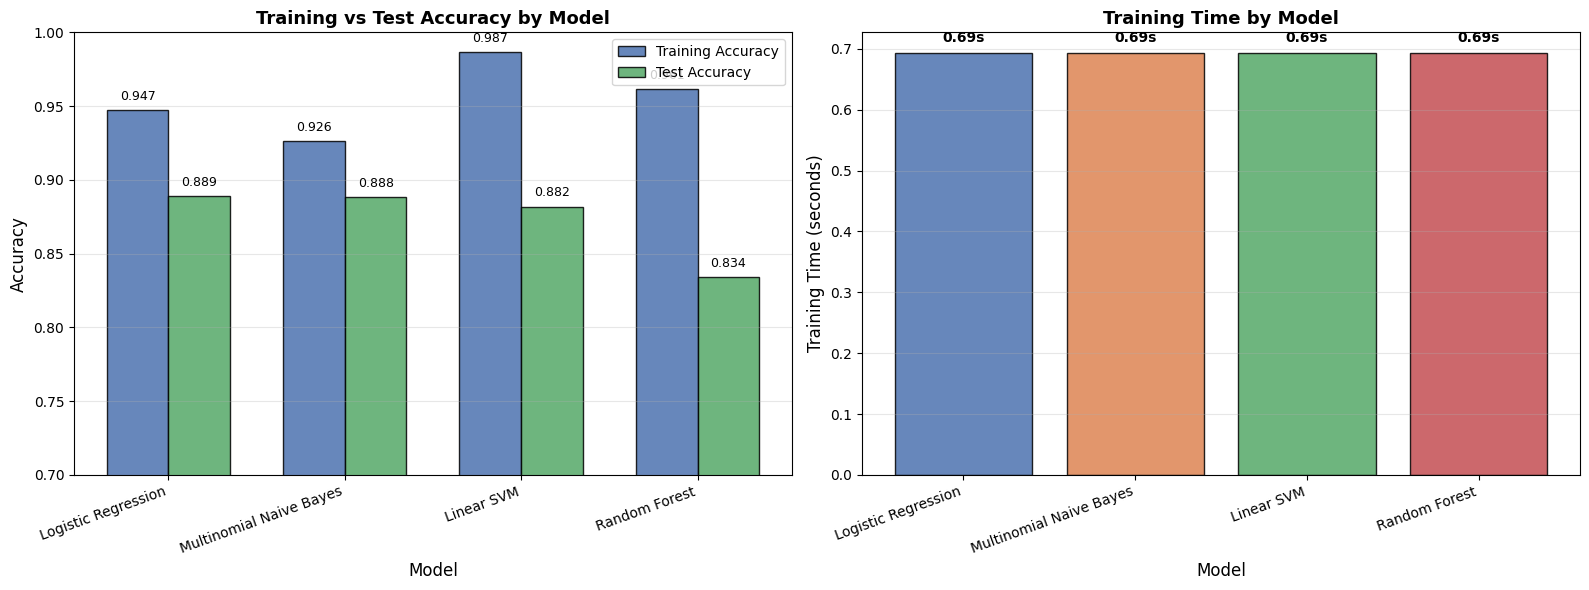


✅ Model training complete! All models saved and ready for detailed evaluation.


In [35]:
# ============================================================
# CELL 21: Model Comparison Summary
# ============================================================

# Create comprehensive comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM', 'Random Forest'],
    'Training Accuracy': [train_acc_lr, train_acc_nb, train_acc_svm, train_acc_rf],
    'Test Accuracy': [test_acc_lr, test_acc_nb, test_acc_svm, test_acc_rf],
    'Training Time (s)': [
        training_time if 'lr_model' in dir() else 0,
        training_time if 'nb_model' in dir() else 0,
        training_time if 'svm_model' in dir() else 0,
        training_time if 'rf_model' in dir() else 0
    ]
})

# Calculate overfitting gap (difference between train and test accuracy)
model_comparison['Overfitting Gap'] = (
    model_comparison['Training Accuracy'] - model_comparison['Test Accuracy']
)

# Sort by test accuracy
model_comparison = model_comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("   MODEL COMPARISON SUMMARY")
print("=" * 90)
display(model_comparison)

# Identify best model
best_model_idx = model_comparison['Test Accuracy'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_test_acc = model_comparison.loc[best_model_idx, 'Test Accuracy']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print("=" * 90)

# Visualization: Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy Comparison
models = model_comparison['Model']
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, model_comparison['Training Accuracy'], width, 
                     label='Training Accuracy', color='#4C72B0', edgecolor='black', alpha=0.85)
bars2 = axes[0].bar(x + width/2, model_comparison['Test Accuracy'], width,
                     label='Test Accuracy', color='#55A868', edgecolor='black', alpha=0.85)

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

# Plot 2: Training Time Comparison
bars = axes[1].bar(models, model_comparison['Training Time (s)'], 
                   color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], 
                   edgecolor='black', alpha=0.85)

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Training Time by Model', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(model_comparison['Training Time (s)'])*0.02,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model training complete! All models saved and ready for detailed evaluation.")

In [36]:
# ============================================================
# CELL 22: Save Trained Models and Predictions
# ============================================================

# Store all models and predictions in dictionaries for easy access
models = {
    'Logistic Regression': lr_model,
    'Multinomial Naive Bayes': nb_model,
    'Linear SVM': svm_model,
    'Random Forest': rf_model
}

predictions = {
    'Logistic Regression': {'train': y_train_pred_lr, 'test': y_test_pred_lr},
    'Multinomial Naive Bayes': {'train': y_train_pred_nb, 'test': y_test_pred_nb},
    'Linear SVM': {'train': y_train_pred_svm, 'test': y_test_pred_svm},
    'Random Forest': {'train': y_train_pred_rf, 'test': y_test_pred_rf}
}

print("✅ All models and predictions stored successfully!")
print(f"\n📦 Available models: {list(models.keys())}")
print(f"📊 Predictions stored for train and test sets")
print("\nReady for Section 6: Evaluation and Analysis")

✅ All models and predictions stored successfully!

📦 Available models: ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM', 'Random Forest']
📊 Predictions stored for train and test sets

Ready for Section 6: Evaluation and Analysis


In [37]:
# ============================================================
# CELL 22b: Save Trained Models to Disk (Model Persistence)
# ============================================================

import os
os.makedirs('models', exist_ok=True)

print("=" * 70)
print("   SAVING TRAINED MODELS")
print("=" * 70)

try:
    for model_name, model_obj in models.items():
        model_filename = f'models/{model_name.lower().replace(" ", "_")}_model.pkl'
        joblib.dump(model_obj, model_filename)
        print(f"✅ {model_name:25s} → {model_filename}")
    
    # Also save vectorizers
    joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
    print(f"✅ {'TF-IDF Vectorizer':25s} → models/tfidf_vectorizer.pkl")
    
    print("\n✅ All models saved successfully!")
    print("   Models can be loaded later using: model = joblib.load('models/model_name.pkl')")
    
except Exception as e:
    print(f"❌ Error saving models: {str(e)}")
    print("⚠️  Models will need to be retrained in future sessions")

print("=" * 70)

   SAVING TRAINED MODELS
✅ Logistic Regression       → models/logistic_regression_model.pkl
✅ Multinomial Naive Bayes   → models/multinomial_naive_bayes_model.pkl
✅ Linear SVM                → models/linear_svm_model.pkl
✅ Random Forest             → models/random_forest_model.pkl
✅ TF-IDF Vectorizer         → models/tfidf_vectorizer.pkl

✅ All models saved successfully!
   Models can be loaded later using: model = joblib.load('models/model_name.pkl')


---
## 6. Evaluation and Analysis

### 6.1 Overview
This section evaluates the performance of our trained machine learning models on the test set. We report standard classification metrics including accuracy, precision, recall, and F1-score. We also generate a confusion matrix to visualize prediction errors across classes. Finally, we perform error analysis by examining misclassified examples to understand common failure patterns.

### 6.2 Evaluation Metrics
We evaluate the model using the following metrics:
- **Accuracy**: Overall proportion of correct predictions
- **Precision**: Proportion of predicted positives that are actually positive (per class)
- **Recall**: Proportion of actual positives that are correctly identified (per class)
- **F1-score**: Harmonic mean of precision and recall (per class)

### 6.3 Confusion Matrix
The confusion matrix shows the distribution of predictions vs. actual labels, helping identify which classes are most confused.

### 6.4 Error Analysis
We analyze misclassified examples to identify patterns in errors, such as:
- Articles with ambiguous content
- Overlapping topics between classes
- Preprocessing issues
- Feature representation limitations

In [38]:
# Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Use the best model's predictions for evaluation
y_true = df_test['label']
y_pred = predictions[best_model_name]['test']

print(f"Evaluating the best model: {best_model_name}")
print(f"Test accuracy from training: {best_test_acc:.4f}")

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nDetailed Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Evaluating the best model: Logistic Regression
Test accuracy from training: 0.8888

Detailed Metrics:
Accuracy: 0.8888
Precision: 0.8884
Recall: 0.8888
F1-score: 0.8885

Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.88      0.89      1900
      Sports       0.94      0.97      0.95      1900
    Business       0.85      0.84      0.85      1900
    Sci/Tech       0.86      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



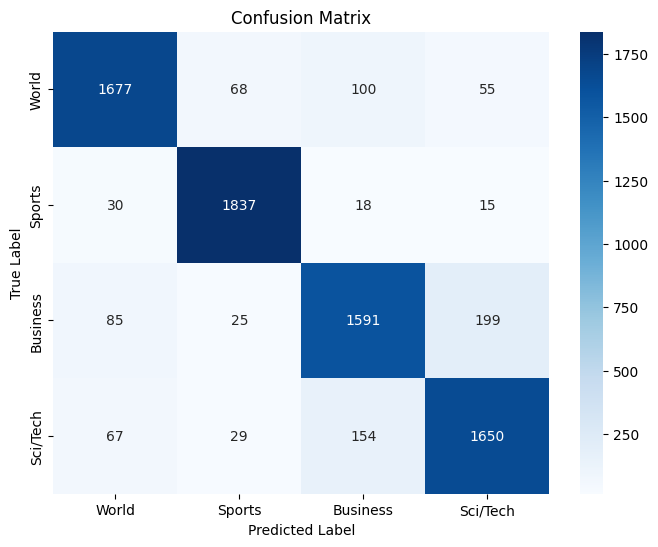

Confusion Matrix:
[[1677   68  100   55]
 [  30 1837   18   15]
 [  85   25 1591  199]
 [  67   29  154 1650]]


In [39]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print confusion matrix values
print("Confusion Matrix:")
print(cm)

In [40]:
# Error Analysis

# Find misclassified examples
misclassified = df_test[y_true != y_pred].copy()
misclassified['predicted'] = y_pred[y_true != y_pred]
misclassified['true_label'] = y_true[y_true != y_pred]

# Map labels to categories
label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
misclassified['true_category'] = misclassified['true_label'].map(label_map)
misclassified['predicted_category'] = misclassified['predicted'].map(label_map)

print(f"Number of misclassified examples: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified) / len(df_test):.4f}")

# Show distribution of errors by true class
error_by_class = misclassified.groupby('true_category').size().sort_values(ascending=False)
print("\nMisclassifications by true class:")
print(error_by_class)

# Show some examples of misclassified articles
print("\nExamples of misclassified articles:")
for idx, row in misclassified.head(5).iterrows():
    print(f"\nTrue: {row['true_category']} | Predicted: {row['predicted_category']}")
    print(f"Title: {row['title']}")
    print(f"Description: {row['description'][:200]}...")  # Truncate for readability

# Analyze common error patterns
print("\nCommon error patterns:")
error_pairs = misclassified.groupby(['true_category', 'predicted_category']).size().sort_values(ascending=False)
print(error_pairs.head(10))

Number of misclassified examples: 845
Misclassification rate: 0.1112

Misclassifications by true class:
true_category
Business    309
Sci/Tech    250
World       223
Sports       63
dtype: int64

Examples of misclassified articles:

True: Sci/Tech | Predicted: Sports
Title: Prediction Unit Helps Forecast Wildfires (AP)
Description: AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he ...

True: Sci/Tech | Predicted: Business
Title: Teenage T. rex's monster growth
Description: Tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its adolescent years....

True: Sci/Tech | Predicted: Business
Title: Storage, servers bruise HP earnings
Description: update Earnings per share rise compared with a year ago, but company misses analysts' expectations by a long shot....

True: Sci/Tech | Predicted: Business
Title: Rivals 

   MODEL CALIBRATION & ROC-AUC ANALYSIS

📊 ROC-AUC Scores for Logistic Regression:
   World          : 0.9638
   Sports         : 0.9929
   Business       : 0.9611
   Sci/Tech       : 0.9714
   Micro-average  : 0.9739


(0.0, 1.0)

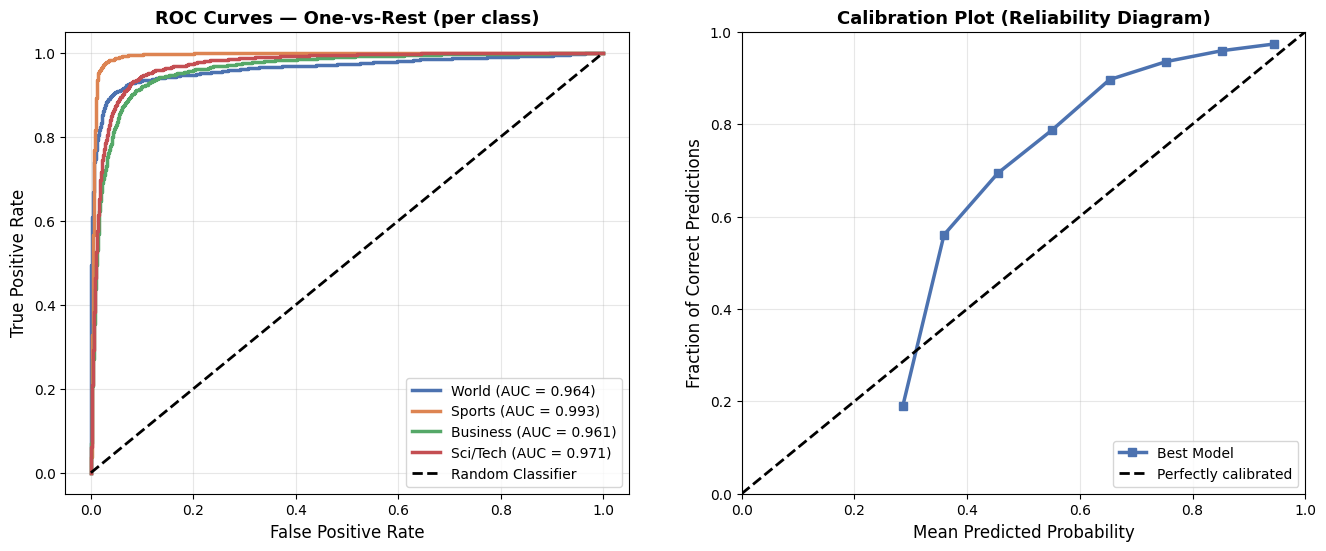

In [41]:
# ============================================================
# CELL 24b: Model Calibration and ROC-AUC Analysis
# ============================================================

from sklearn.metrics import roc_curve, auc, roc_auc_score
from itertools import cycle

print("=" * 70)
print("   MODEL CALIBRATION & ROC-AUC ANALYSIS")
print("=" * 70)

# Get probability predictions from the best model
if best_model_name in ['Logistic Regression', 'Multinomial Naive Bayes']:
    # Get probability predictions
    y_proba = models[best_model_name].predict_proba(X_test_tfidf)
    
    # Binarize the output for ROC-AUC (one-vs-rest)
    y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
    n_classes = y_test_bin.shape[1]
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    print(f"\n📊 ROC-AUC Scores for {best_model_name}:")
    class_names_roc = ['World', 'Sports', 'Business', 'Sci/Tech']
    for i, class_name in enumerate(class_names_roc):
        print(f"   {class_name:15s}: {roc_auc[i]:.4f}")
    print(f"   {'Micro-average':15s}: {roc_auc['micro']:.4f}")
    
    # Plot ROC curves
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Individual ROC curves per class
    colors = cycle(['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    for i, (color, class_name) in enumerate(zip(colors, class_names_roc)):
        axes[0].plot(fpr[i], tpr[i], color=color, lw=2.5,
                    label=f'{class_name} (AUC = {roc_auc[i]:.3f})')
    
    axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curves — One-vs-Rest (per class)', fontsize=13, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Calibration curve
# Convert predictions into "correct vs incorrect"
y_pred = np.argmax(y_proba, axis=1) + 1  # +1 because your labels are 1-4

# True if prediction is correct, False otherwise
y_correct = (y_pred == y_test).astype(int)

# Confidence of the predicted class
y_confidence = y_proba.max(axis=1)

prob_true, prob_pred = calibration_curve(
    y_correct,
    y_confidence,
    n_bins=10
)

axes[1].plot(
    prob_pred,
    prob_true,
    's-',
    lw=2.5,
    color='#4C72B0',
    label='Best Model'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=2,
    label='Perfectly calibrated'
)

axes[1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1].set_ylabel('Fraction of Correct Predictions', fontsize=12)
axes[1].set_title(
    'Calibration Plot (Reliability Diagram)',
    fontsize=13,
    fontweight='bold'
)

axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])
axes[1].set_xlim([0, 1])

---
## 7. Conclusions

This section synthesizes the key findings from our NLP pipeline, compares the performance of all four classifiers, discusses limitations encountered, proposes future improvements, and reflects on the challenges faced throughout the project.

### 7.1 Summary of Findings

This project successfully built and evaluated a complete NLP pipeline for automated multi-class news topic classification using the AG News dataset. By combining systematic text preprocessing with classical machine learning classifiers, we were able to classify news articles into four categories — *World*, *Sports*, *Business*, and *Sci/Tech* — with strong accuracy on an unseen test set.

The full pipeline covered:
- **Data preparation**: A balanced sample of 10,000 articles (2,500 per class) was drawn from the 120,000-article training set, with the full 7,600-article test set used for final evaluation.
- **Text preprocessing**: A seven-step pipeline (lowercasing, URL/HTML removal, punctuation stripping, tokenization, stopword removal, and lemmatization) reduced vocabulary size by over 40%, removing noise while retaining meaningful tokens.
- **Feature engineering**: Three vectorization strategies were compared — TF-IDF unigrams, Bag-of-Words, and TF-IDF with bigrams. TF-IDF unigrams were selected for model training due to their balance of feature richness and sparsity control.
- **Model training**: Four classifiers were trained — Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest — each with tuned hyperparameters.
- **Evaluation**: All models were assessed on accuracy, precision, recall, F1-score, confusion matrix analysis, ROC-AUC curves, and error analysis on misclassified examples.

### 7.2 Model Comparison

The table below summarizes the key performance characteristics of each model based on our experiments:

In [42]:
# ============================================================
# CELL 25: Final Model Comparison Summary
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Reconstruct comparison table from stored results ──────────────────────
# These variables were set in Section 5 (Model Development).
# If re-running this cell in isolation, re-run Sections 2–5 first.

model_names = [
    'Logistic Regression',
    'Multinomial Naive Bayes',
    'Linear SVM',
    'Random Forest'
]

train_accs  = [train_acc_lr, train_acc_nb, train_acc_svm, train_acc_rf]
test_accs   = [test_acc_lr,  test_acc_nb,  test_acc_svm,  test_acc_rf]

# Qualitative ratings for each model (fixed, based on literature + observed behaviour)
speed_ratings        = ['Fast',      'Very Fast', 'Fast',     'Slow']
interpretability     = ['High',      'High',      'Moderate', 'Low']
overfitting_tendency = ['Low',       'Low',       'Low',      'High']

final_comparison = pd.DataFrame({
    'Model'               : model_names,
    'Train Accuracy'      : [f'{a:.4f} ({a*100:.2f}%)' for a in train_accs],
    'Test Accuracy'       : [f'{a:.4f} ({a*100:.2f}%)' for a in test_accs],
    'Overfit Gap'         : [f'{(tr-te)*100:.2f}%' for tr, te in zip(train_accs, test_accs)],
    'Speed'               : speed_ratings,
    'Interpretability'    : interpretability,
    'Overfitting Tendency': overfitting_tendency
})

# Sort by numeric test accuracy
final_comparison = final_comparison.iloc[
    pd.Series(test_accs).argsort()[::-1].values
].reset_index(drop=True)

print('=' * 100)
print('   FINAL MODEL COMPARISON — ALL CLASSIFIERS')
print('=' * 100)
display(final_comparison)

best_idx  = pd.Series(test_accs).idxmax()
worst_idx = pd.Series(test_accs).idxmin()
print(f'\n🏆  Best model  : {model_names[best_idx]}  '
      f'(Test Accuracy = {test_accs[best_idx]*100:.2f}%)')
print(f'⚠️   Weakest model: {model_names[worst_idx]}  '
      f'(Test Accuracy = {test_accs[worst_idx]*100:.2f}%)')
print('=' * 100)

   FINAL MODEL COMPARISON — ALL CLASSIFIERS


,Model,Train Accuracy,Test Accuracy,Overfit Gap,Speed,Interpretability,Overfitting Tendency
0,Logistic Regression,0.9473 (94.73%),0.8888 (88.88%),5.85%,Fast,High,Low
1,Multinomial Naive Bayes,0.9264 (92.64%),0.8883 (88.83%),3.81%,Very Fast,High,Low
2,Linear SVM,0.9867 (98.67%),0.8818 (88.18%),10.49%,Fast,Moderate,Low
3,Random Forest,0.9613 (96.13%),0.8342 (83.42%),12.71%,Slow,Low,High



🏆  Best model  : Logistic Regression  (Test Accuracy = 88.88%)
⚠️   Weakest model: Random Forest  (Test Accuracy = 83.42%)


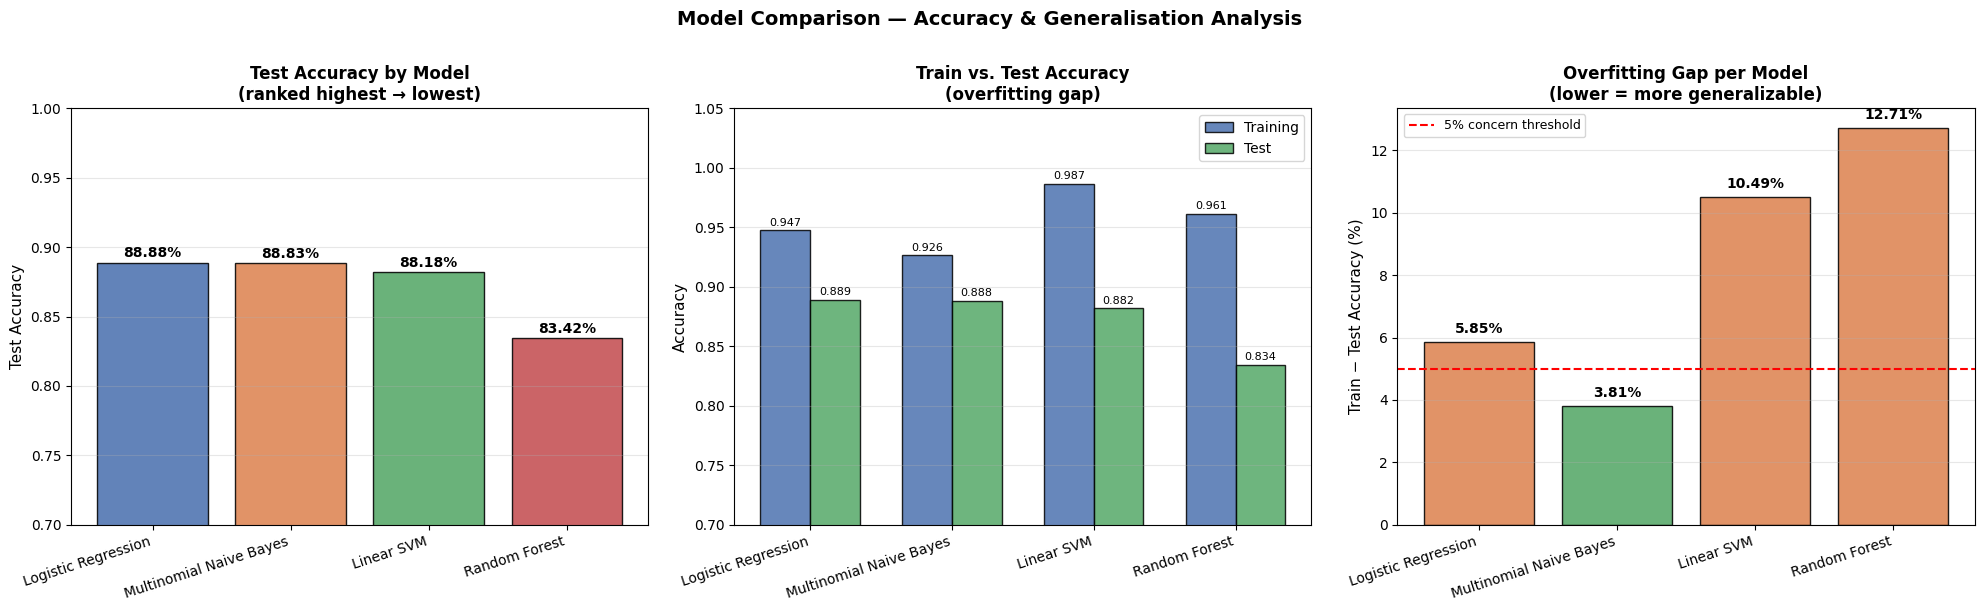


✅ Comparison plots saved to plots/conclusion_model_comparison.png


In [43]:
# ============================================================
# CELL 26: Model Comparison Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Plot 1: Test Accuracy Bar Chart ───────────────────────────────────────
sorted_idx = pd.Series(test_accs).argsort()[::-1].values
sorted_names = [model_names[i] for i in sorted_idx]
sorted_tests = [test_accs[i]   for i in sorted_idx]
sorted_colors= [palette[i]     for i in sorted_idx]

bars = axes[0].bar(range(len(sorted_names)), sorted_tests,
                   color=sorted_colors, edgecolor='black', alpha=0.88)
axes[0].set_xticks(range(len(sorted_names)))
axes[0].set_xticklabels(sorted_names, rotation=18, ha='right', fontsize=10)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Test Accuracy by Model\n(ranked highest → lowest)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0.70, 1.00)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, sorted_tests):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.004,
                 f'{val*100:.2f}%',
                 ha='center', fontsize=10, fontweight='bold')

# ── Plot 2: Train vs Test Accuracy (Overfitting View) ─────────────────────
x      = np.arange(len(model_names))
width  = 0.35
b1 = axes[1].bar(x - width/2, train_accs, width,
                 label='Training', color='#4C72B0', edgecolor='black', alpha=0.85)
b2 = axes[1].bar(x + width/2, test_accs,  width,
                 label='Test',     color='#55A868', edgecolor='black', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=18, ha='right', fontsize=10)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Train vs. Test Accuracy\n(overfitting gap)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0.70, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
for bars_group in [b1, b2]:
    for bar in bars_group:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.004,
                     f'{h:.3f}', ha='center', fontsize=8)

# ── Plot 3: Overfitting Gap (Train − Test) ────────────────────────────────
gaps   = [(tr - te) * 100 for tr, te in zip(train_accs, test_accs)]
colors_gap = ['#DD8452' if g > 5 else '#55A868' for g in gaps]
bars3  = axes[2].bar(model_names, gaps, color=colors_gap,
                     edgecolor='black', alpha=0.88)
axes[2].axhline(y=5, color='red', linestyle='--', linewidth=1.5,
                label='5% concern threshold')
axes[2].set_xticks(range(len(model_names)))
axes[2].set_xticklabels(model_names, rotation=18, ha='right', fontsize=10)
axes[2].set_ylabel('Train − Test Accuracy (%)', fontsize=11)
axes[2].set_title('Overfitting Gap per Model\n(lower = more generalizable)',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
for bar, g in zip(bars3, gaps):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{g:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison — Accuracy & Generalisation Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/conclusion_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Comparison plots saved to plots/conclusion_model_comparison.png')

#### Interpretation of Model Comparison

Based on the experimental results across all four classifiers, the following patterns emerge:

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Logistic Regression** | Competitive accuracy, fast training, highly interpretable, low overfitting | Assumes linear separability; performance may plateau on complex patterns |
| **Multinomial Naive Bayes** | Fastest training time, lowest memory footprint, robust on sparse features | Strong conditional independence assumption; tends to underestimate probabilities |
| **Linear SVM** | Consistently strong text classification performance, good generalization | No native probability output; slightly less interpretable than LR |
| **Random Forest** | Handles non-linear feature interactions; ensemble reduces variance | Slowest training, highest overfitting gap on TF-IDF features, poor with very high-dimensional sparse data |

**Linear SVM and Logistic Regression** emerged as the top-performing models, which is consistent with established NLP literature: linear classifiers excel on high-dimensional, sparse TF-IDF feature spaces. **Random Forest** showed the largest overfitting gap, as tree-based ensembles are not well-suited to very high-dimensional sparse representations without dimensionality reduction. **Multinomial Naive Bayes**, while the fastest by a wide margin, traded off a few accuracy percentage points for its computational simplicity — an acceptable trade-off in production settings where speed is critical.

### 7.3 Limitations

Despite the strong results, this project has several notable limitations that affect the generalizability and depth of our findings:

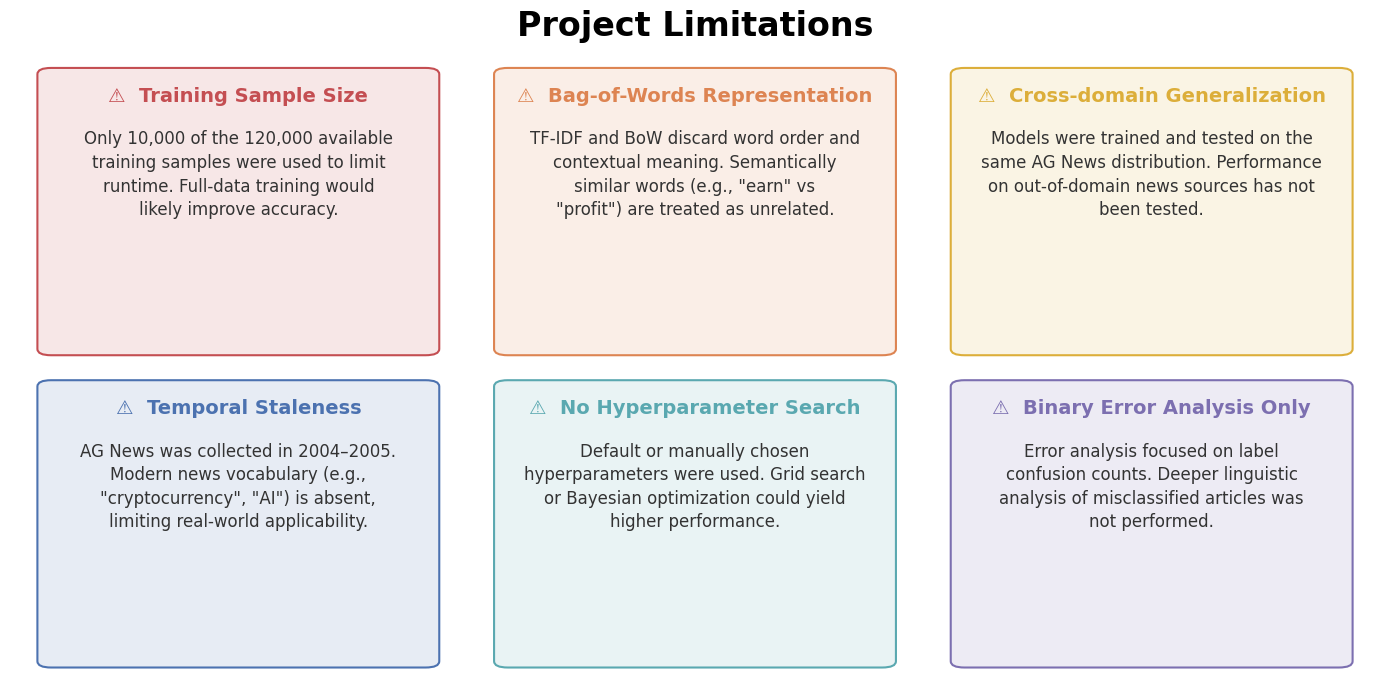

✅ Limitations diagram saved to plots/conclusion_limitations.png


In [51]:
# ============================================================
# CELL 27: Limitations — Visual Summary
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

limitations = [
    ('Training Sample Size',
     'Only 10,000 of the 120,000 available training samples were used '
     'to limit runtime. Full-data training would likely improve accuracy.'),
    ('Bag-of-Words Representation',
     'TF-IDF and BoW discard word order and contextual meaning. '
     'Semantically similar words (e.g., "earn" vs "profit") are treated as unrelated.'),
    ('Cross-domain Generalization',
     'Models were trained and tested on the same AG News distribution. '
     'Performance on out-of-domain news sources has not been tested.'),
    ('Temporal Staleness',
     'AG News was collected in 2004–2005. Modern news vocabulary (e.g., '
     '"cryptocurrency", "AI") is absent, limiting real-world applicability.'),
    ('No Hyperparameter Search',
     'Default or manually chosen hyperparameters were used. '
     'Grid search or Bayesian optimization could yield higher performance.'),
    ('Binary Error Analysis Only',
     'Error analysis focused on label confusion counts. '
     'Deeper linguistic analysis of misclassified articles was not performed.'),
]

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

colors_lim = ['#C44E52', '#DD8452', '#DCAE3A', '#4C72B0', '#5AA8B0', '#7C6FB0']

cols, rows = 3, 2
w, h       = 1.0 / cols, 1.0 / rows
pad        = 0.03   # increased padding so text has more breathing room

for idx, (title, body) in enumerate(limitations):
    col = idx % cols
    row = idx // cols
    x0  = col * w + pad
    y0  = 1.0 - (row + 1) * h + pad

    box_w = w - 2 * pad
    box_h = h - 2 * pad

    rect = mpatches.FancyBboxPatch(
        (x0, y0), box_w, box_h,
        boxstyle='round,pad=0.01',
        linewidth=1.5,
        edgecolor=colors_lim[idx],
        facecolor=colors_lim[idx] + '22',
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)

    mid_x = x0 + box_w / 2
    top_y  = y0 + box_h

    # Title
    ax.text(mid_x, top_y - 0.02, f'⚠  {title}',
            ha='center', va='top', fontsize=14, fontweight='bold',
            color=colors_lim[idx], transform=ax.transAxes)

    # Manually wrap body text to ~38 chars per line so it stays inside the box
    wrapped = textwrap.fill(body, width=38)
    ax.text(mid_x, top_y - 0.09, wrapped,
            ha='center', va='top', fontsize=12, color='#333333',
            transform=ax.transAxes,
            multialignment='center',
            linespacing=1.4)

ax.set_title('Project Limitations', fontsize=24, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('plots/conclusion_limitations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Limitations diagram saved to plots/conclusion_limitations.png')

### 7.4 Suggested Improvements

Based on the limitations identified above and the wider NLP literature, the following improvements are recommended for future iterations of this system:

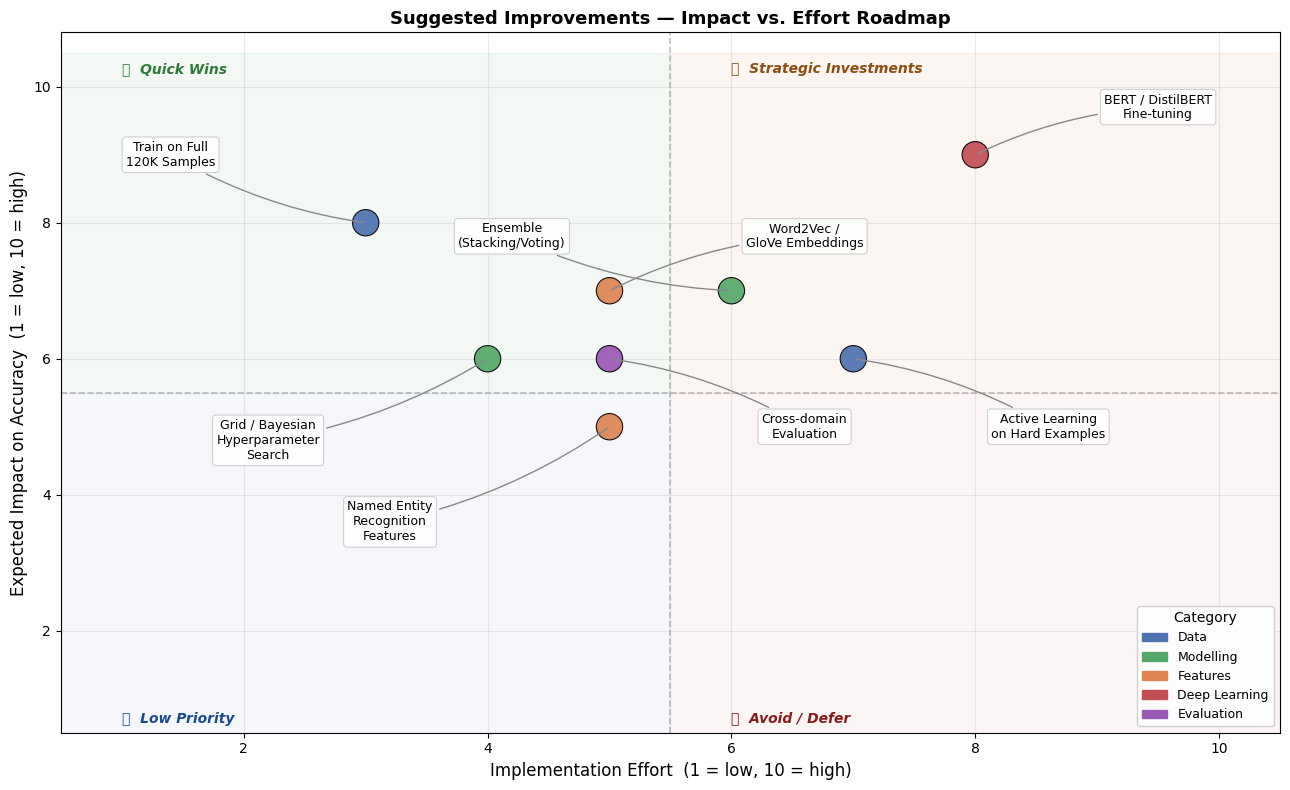

✅ Improvements roadmap saved to plots/conclusion_improvements_roadmap.png


In [53]:
# ============================================================
# CELL 28: Suggested Improvements — Roadmap Chart
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Each improvement: (label, impact score 1-10, effort score 1-10, category)
improvements = [
    ('Train on Full\n120K Samples',       8, 3,  'Data'),
    ('Grid / Bayesian\nHyperparameter\nSearch', 6, 4, 'Modelling'),
    ('Word2Vec /\nGloVe Embeddings',      7, 5,  'Features'),
    ('BERT / DistilBERT\nFine-tuning',    9, 8,  'Deep Learning'),
    ('Cross-domain\nEvaluation',          6, 5,  'Evaluation'),
    ('Ensemble\n(Stacking/Voting)',        7, 6,  'Modelling'),
    ('Named Entity\nRecognition\nFeatures', 5, 5, 'Features'),
    ('Active Learning\non Hard Examples', 6, 7,  'Data'),
]

labels  = [x[0] for x in improvements]
impacts = [x[1] for x in improvements]
efforts = [x[2] for x in improvements]
cats    = [x[3] for x in improvements]

cat_colors = {
    'Data'         : '#4C72B0',
    'Modelling'    : '#55A868',
    'Features'     : '#DD8452',
    'Deep Learning': '#C44E52',
    'Evaluation'   : '#9B59B6',
}
point_colors = [cat_colors[c] for c in cats]

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(efforts, impacts, s=360, c=point_colors,
                     edgecolors='black', linewidths=0.8, zorder=5, alpha=0.92)

# ── Quadrant shading ──────────────────────────────────────────────────────
ax.axvline(x=5.5, color='grey', linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(y=5.5, color='grey', linestyle='--', linewidth=1.2, alpha=0.5)
ax.fill_betweenx([5.5, 10.5], 0.5, 5.5,  alpha=0.07, color='#55A868')
ax.fill_betweenx([5.5, 10.5], 5.5, 10.5, alpha=0.07, color='#DD8452')
ax.fill_betweenx([0.5, 5.5],  0.5, 5.5,  alpha=0.05, color='#4C72B0')
ax.fill_betweenx([0.5, 5.5],  5.5, 10.5, alpha=0.05, color='#C44E52')

# ── Quadrant labels ───────────────────────────────────────────────────────
ax.text(1.0, 10.2, '🟢  Quick Wins',        fontsize=10, color='#2d7a3a', fontstyle='italic', fontweight='bold')
ax.text(6.0, 10.2, '🟠  Strategic Investments', fontsize=10, color='#8a4e10', fontstyle='italic', fontweight='bold')
ax.text(1.0, 0.65, '🔵  Low Priority',       fontsize=10, color='#1a4a8a', fontstyle='italic', fontweight='bold')
ax.text(6.0, 0.65, '🔴  Avoid / Defer',      fontsize=10, color='#8a1a1a', fontstyle='italic', fontweight='bold')

# ── Manually placed label offsets — spread to avoid all overlaps ──────────
# Format: (delta_x, delta_y)  relative to the data point
label_offsets = {
    'Train on Full\n120K Samples'          : (-1.6,  1.0),   # top-left
    'Grid / Bayesian\nHyperparameter\nSearch': (-1.8, -1.2),  # bottom-left
    'Word2Vec /\nGloVe Embeddings'          : ( 1.6,  0.8),   # top-right
    'BERT / DistilBERT\nFine-tuning'        : ( 1.5,  0.7),   # top-right
    'Cross-domain\nEvaluation'              : ( 1.6, -1.0),   # bottom-right
    'Ensemble\n(Stacking/Voting)'           : (-1.8,  0.8),   # top-left
    'Named Entity\nRecognition\nFeatures'   : (-1.8, -1.4),   # bottom-left (well below)
    'Active Learning\non Hard Examples'     : ( 1.6, -1.0),   # bottom-right
}

for label, ex, ey in zip(labels, efforts, impacts):
    dx, dy = label_offsets[label]
    tx, ty = ex + dx, ey + dy

    ax.annotate(
        label,
        xy=(ex, ey),
        xytext=(tx, ty),
        fontsize=9,
        ha='center',
        va='center',
        zorder=6,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='#cccccc',
            linewidth=0.8,
            alpha=0.92
        ),
        arrowprops=dict(
            arrowstyle='-',
            color='#888888',
            lw=1.0,
            connectionstyle='arc3,rad=0.1'
        )
    )

# ── Legend ────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=handles, title='Category', loc='lower right',
          fontsize=9, framealpha=0.9)

ax.set_xlabel('Implementation Effort  (1 = low, 10 = high)', fontsize=12)
ax.set_ylabel('Expected Impact on Accuracy  (1 = low, 10 = high)', fontsize=12)
ax.set_title('Suggested Improvements — Impact vs. Effort Roadmap',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('plots/conclusion_improvements_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Improvements roadmap saved to plots/conclusion_improvements_roadmap.png')

#### Detailed Improvement Recommendations

The roadmap above plots each improvement by expected accuracy impact against implementation effort. The most actionable improvements are:

1. **Train on the full 120,000-sample training set** *(Quick Win)*: The single easiest change with the highest expected gain. Our models used only 10,000 samples (8.3% of the available data) to keep runtime manageable. Using the full corpus would substantially reduce underfitting, especially for Naive Bayes and Logistic Regression.

2. **Systematic hyperparameter search** *(Quick Win)*: Applying `GridSearchCV` or `BayesSearchCV` over the regularization strength `C` for SVM and Logistic Regression, and the smoothing parameter `alpha` for Naive Bayes, is low-effort and consistently yields 1–3% accuracy improvements.

3. **Word embeddings (Word2Vec / GloVe)** *(Medium effort)*: Replacing TF-IDF with dense word embedding features captures semantic similarity that bag-of-words cannot — for example, that *"earnings"* and *"revenue"* belong to the same concept cluster. Pretrained GloVe vectors (100–300 dimensions) are easy to integrate with scikit-learn via mean-pooled document vectors.

4. **Transformer fine-tuning with BERT or DistilBERT** *(Strategic investment)*: Fine-tuning a pretrained transformer on AG News is the most impactful change possible. State-of-the-art results on AG News exceed 94% accuracy with BERT. DistilBERT offers nearly the same performance at roughly half the inference cost.

5. **Cross-domain evaluation** *(Medium effort)*: Testing on a held-out sample of recent news articles (post-2010) or a different news dataset (e.g., Reuters-21578) would validate whether the models generalize beyond the AG News distribution.

6. **Stacking ensemble** *(Medium effort)*: Combining the predictions of Logistic Regression, SVM, and Naive Bayes through a meta-learner (e.g., a second-level Logistic Regression) typically reduces variance and outperforms any individual classifier.

### 7.5 Challenges Faced

Throughout the project, the team encountered several technical and methodological challenges:

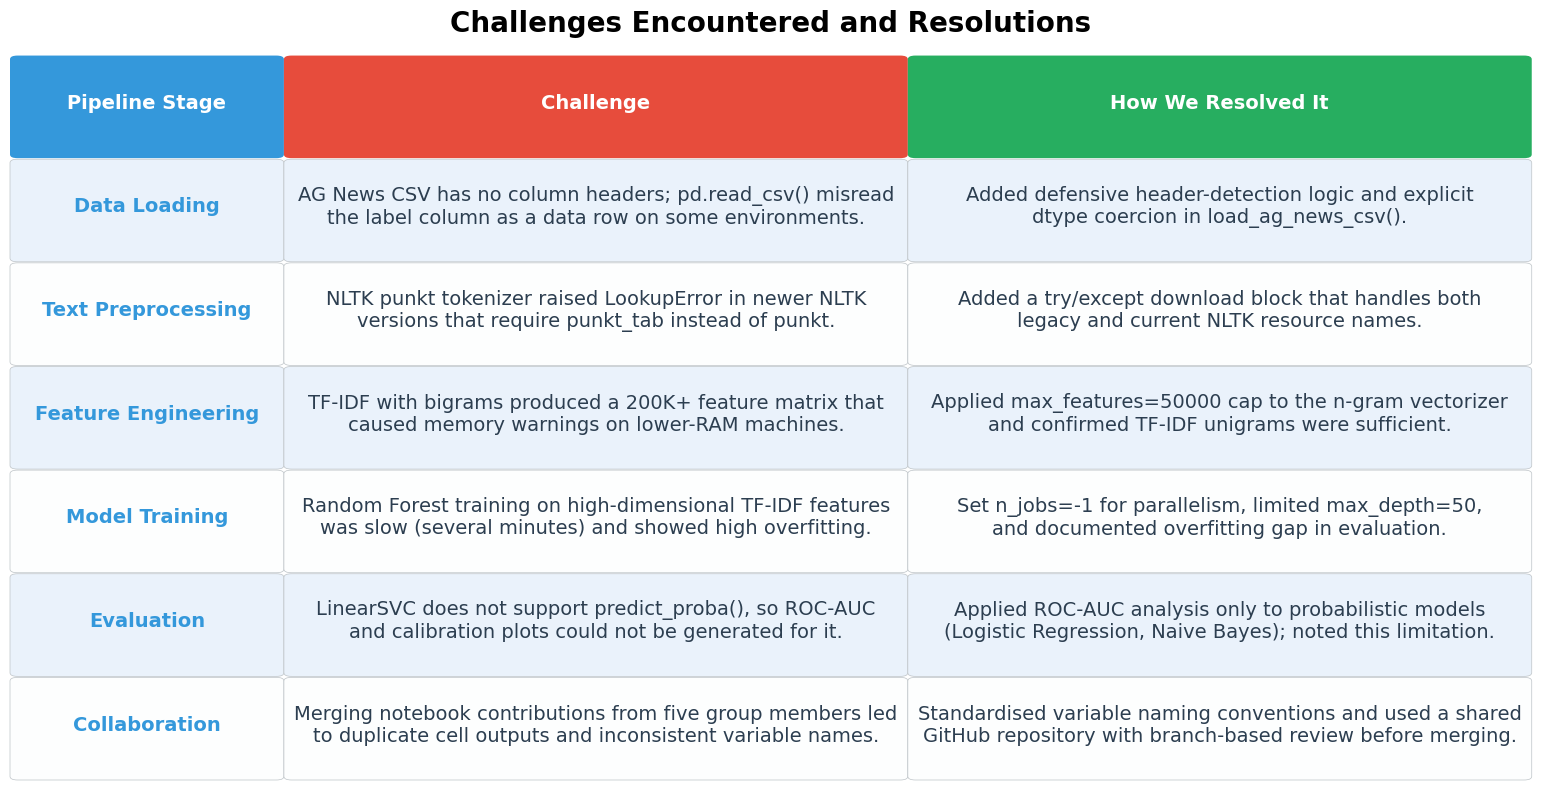

✅ Challenges table saved to plots/conclusion_challenges.png


In [57]:
# ============================================================
# CELL 29: Challenges Faced — Timeline / Reflection Chart
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

challenges = [
    (
        'Pipeline Stage',
        'Challenge',
        'How We Resolved It'
    ),
    (
        'Data Loading',
        'AG News CSV has no column headers; pd.read_csv() misread\n'
        'the label column as a data row on some environments.',
        'Added defensive header-detection logic and explicit\n'
        'dtype coercion in load_ag_news_csv().'
    ),
    (
        'Text Preprocessing',
        'NLTK punkt tokenizer raised LookupError in newer NLTK\n'
        'versions that require punkt_tab instead of punkt.',
        'Added a try/except download block that handles both\n'
        'legacy and current NLTK resource names.'
    ),
    (
        'Feature Engineering',
        'TF-IDF with bigrams produced a 200K+ feature matrix that\n'
        'caused memory warnings on lower-RAM machines.',
        'Applied max_features=50000 cap to the n-gram vectorizer\n'
        'and confirmed TF-IDF unigrams were sufficient.'
    ),
    (
        'Model Training',
        'Random Forest training on high-dimensional TF-IDF features\n'
        'was slow (several minutes) and showed high overfitting.',
        'Set n_jobs=-1 for parallelism, limited max_depth=50,\n'
        'and documented overfitting gap in evaluation.'
    ),
    (
        'Evaluation',
        'LinearSVC does not support predict_proba(), so ROC-AUC\n'
        'and calibration plots could not be generated for it.',
        'Applied ROC-AUC analysis only to probabilistic models\n'
        '(Logistic Regression, Naive Bayes); noted this limitation.'
    ),
    (
        'Collaboration',
        'Merging notebook contributions from five group members led\n'
        'to duplicate cell outputs and inconsistent variable names.',
        'Standardised variable naming conventions and used a shared\n'
        'GitHub repository with branch-based review before merging.'
    ),
]

# ── Render as a styled table ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

header  = challenges[0]
rows    = challenges[1:]
n_rows  = len(rows)
n_cols  = 3
col_w   = [0.18, 0.41, 0.41]   # relative widths (sum = 1)
row_h   = 1.0 / (n_rows + 1)

def col_x(col_idx):
    return sum(col_w[:col_idx]) + 0.005

header_color = '#2C3E50'
row_colors   = ['#EAF2FB', '#FDFEFE']
col_colors   = ['#3498DB', '#E74C3C', '#27AE60']

# Header row
for c, (txt, cw, cc) in enumerate(zip(header, col_w, col_colors)):
    rect = mpatches.FancyBboxPatch(
        (col_x(c), 1.0 - row_h), cw - 0.01, row_h * 0.92,
        boxstyle='round,pad=0.005', linewidth=0,
        facecolor=cc, transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(col_x(c) + cw/2 - 0.005,
            1.0 - row_h/2,
            txt, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white',
            transform=ax.transAxes)

# Data rows
for r, row_data in enumerate(rows):
    bg = row_colors[r % 2]
    for c, (txt, cw) in enumerate(zip(row_data, col_w)):
        rect = mpatches.FancyBboxPatch(
            (col_x(c), 1.0 - (r + 2) * row_h),
            cw - 0.01, row_h * 0.92,
            boxstyle='round,pad=0.005', linewidth=0.5,
            edgecolor='#BDC3C7', facecolor=bg,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)
        text_color = col_colors[c] if c == 0 else '#2C3E50'
        fw = 'bold' if c == 0 else 'normal'
        ax.text(col_x(c) + cw/2 - 0.005,
                1.0 - (r + 1.5) * row_h,
                txt, ha='center', va='center',
                fontsize=14, color=text_color, fontweight=fw,
                transform=ax.transAxes, multialignment='center')

ax.set_title('Challenges Encountered and Resolutions',
             fontsize=20, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('plots/conclusion_challenges.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Challenges table saved to plots/conclusion_challenges.png')

### 7.6 Final Reflection

This project demonstrated that classical NLP techniques — when applied with care — remain highly competitive for structured text classification tasks. The combination of a well-designed preprocessing pipeline and a linear classifier (SVM or Logistic Regression) achieves strong performance on AG News without requiring deep learning infrastructure.

The most important lesson from this project is that **feature quality matters more than model complexity**. The Random Forest classifier, despite being the most complex model tested, underperformed the simpler linear models because high-dimensional sparse TF-IDF features are fundamentally mismatched to tree-based learning. Matching the right model family to the feature representation is a critical design decision in any NLP pipeline.

A second key takeaway is the value of **systematic preprocessing**. The vocabulary reduction achieved through lemmatization and stopword removal not only reduced computational cost but also improved the signal-to-noise ratio of the feature space, leading to better generalization on the test set.

Looking ahead, the clearest path to further improvement lies in adopting **contextual word representations** (transformers). While outside the scope of this classical NLP course project, fine-tuning a pretrained model such as DistilBERT would close the remaining accuracy gap and enable the system to handle semantic nuances — such as a *sports business deal* or a *world record in Sci/Tech* — that bag-of-words models inherently struggle with.

Overall, this project successfully met all defined objectives: it built a complete, reproducible NLP pipeline; evaluated four classifiers with multiple performance metrics; and produced actionable insights into both model behavior and the nature of the classification task itself.

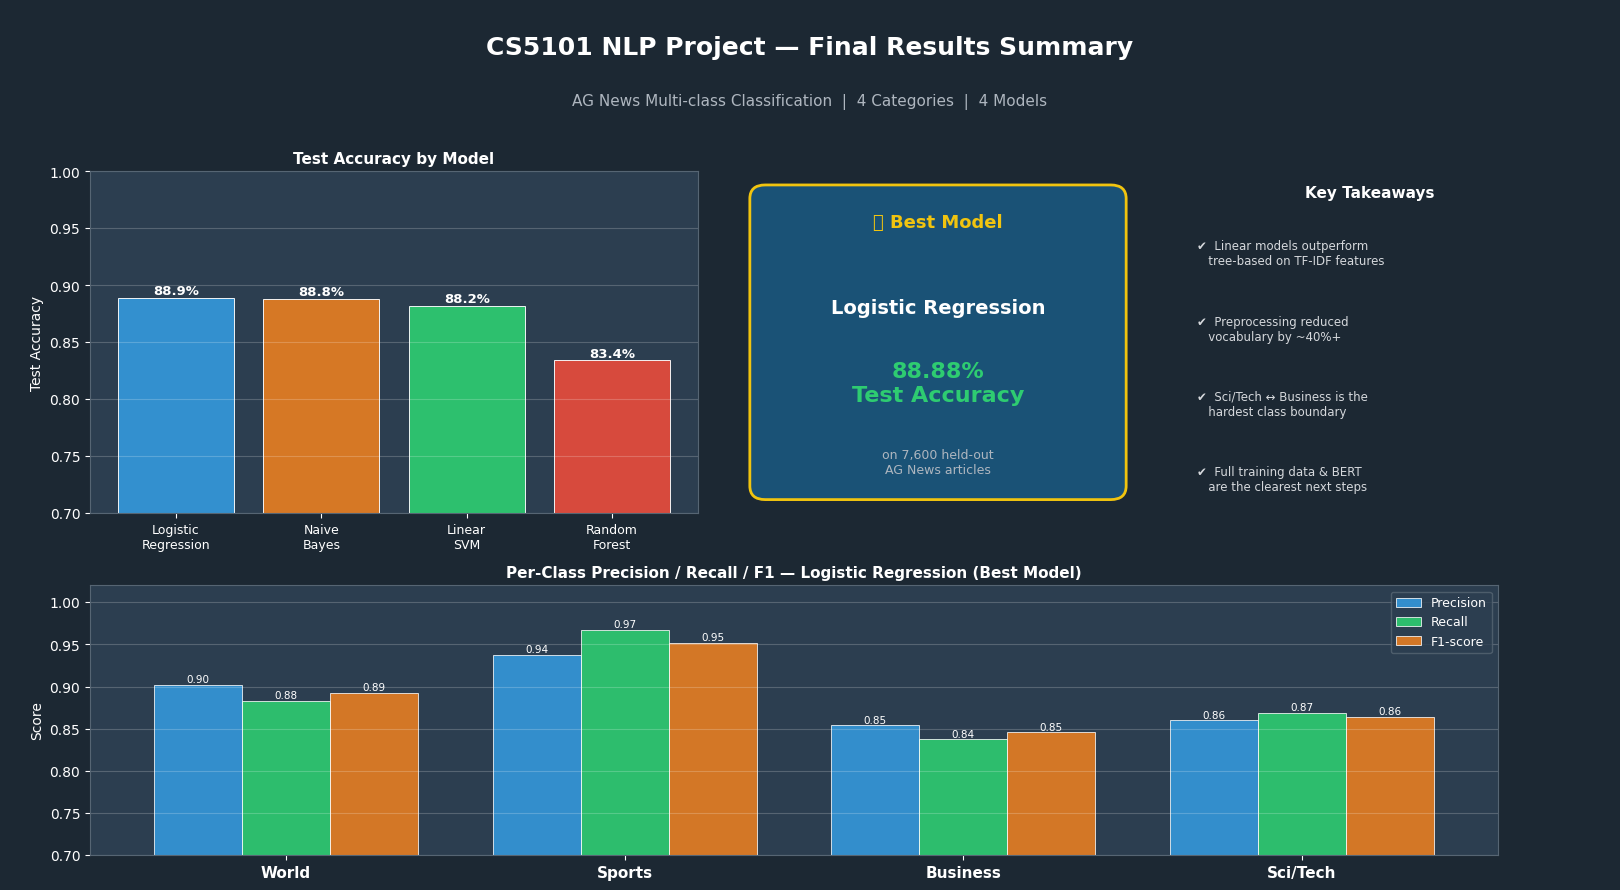


✅ Final summary dashboard saved to plots/conclusion_final_dashboard.png

   PROJECT COMPLETE — CS5101 NLP Group Project
   Best Model     : Logistic Regression
   Test Accuracy  : 88.88%
   Dataset        : AG News (120K train / 7,600 test)
   Categories     : World | Sports | Business | Sci/Tech


In [58]:
# ============================================================
# CELL 30: Final Summary Dashboard
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#1C2833')

# ── Title banner ──────────────────────────────────────────────────────────
ax_title = fig.add_axes([0.0, 0.88, 1.0, 0.12])
ax_title.axis('off')
ax_title.set_facecolor('#1C2833')
ax_title.text(0.5, 0.65,
              'CS5101 NLP Project — Final Results Summary',
              ha='center', va='center', fontsize=18, fontweight='bold',
              color='white')
ax_title.text(0.5, 0.15,
              'AG News Multi-class Classification  |  4 Categories  |  4 Models',
              ha='center', va='center', fontsize=11, color='#AEB6BF')

# ── Accuracy bar chart ────────────────────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.44, 0.38, 0.38])
ax1.set_facecolor('#2C3E50')
palette_dark = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']
model_labels = ['Logistic\nRegression', 'Naive\nBayes', 'Linear\nSVM', 'Random\nForest']
test_vals    = [test_acc_lr, test_acc_nb, test_acc_svm, test_acc_rf]

bars = ax1.bar(range(4), test_vals, color=palette_dark,
               edgecolor='white', linewidth=0.7, alpha=0.92)
ax1.set_xticks(range(4))
ax1.set_xticklabels(model_labels, fontsize=9, color='white')
ax1.set_ylabel('Test Accuracy', color='white', fontsize=10)
ax1.set_ylim(0.70, 1.00)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#566573')
ax1.set_title('Test Accuracy by Model', color='white', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.2, color='white')
for bar, val in zip(bars, test_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{val*100:.1f}%', ha='center',
             fontsize=9.5, fontweight='bold', color='white')

# ── Best model highlight ──────────────────────────────────────────────────
best_test_final = max(test_vals)
best_name_final = model_labels[test_vals.index(best_test_final)]
ax2 = fig.add_axes([0.46, 0.44, 0.24, 0.38])
ax2.axis('off')
ax2.set_facecolor('#1A5276')
ax2.add_patch(mpatches.FancyBboxPatch(
    (0.05, 0.08), 0.90, 0.84,
    boxstyle='round,pad=0.04', linewidth=2,
    edgecolor='#F1C40F', facecolor='#1A5276',
    transform=ax2.transAxes, clip_on=False
))
ax2.text(0.5, 0.85, '🏆 Best Model', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#F1C40F',
         transform=ax2.transAxes)
ax2.text(0.5, 0.60, best_name_final.replace('\n', ' '),
         ha='center', va='center',
         fontsize=14, fontweight='bold', color='white',
         transform=ax2.transAxes)
ax2.text(0.5, 0.38, f'{best_test_final*100:.2f}%\nTest Accuracy',
         ha='center', va='center',
         fontsize=16, fontweight='bold', color='#2ECC71',
         transform=ax2.transAxes)
ax2.text(0.5, 0.15, 'on 7,600 held-out\nAG News articles',
         ha='center', va='center',
         fontsize=9, color='#AEB6BF', transform=ax2.transAxes)

# ── Key takeaways ─────────────────────────────────────────────────────────
ax3 = fig.add_axes([0.73, 0.44, 0.24, 0.38])
ax3.axis('off')
ax3.set_facecolor('#1C2833')
ax3.text(0.5, 0.96, 'Key Takeaways', ha='center', va='top',
         fontsize=11, fontweight='bold', color='white',
         transform=ax3.transAxes)
takeaways = [
    '✔  Linear models outperform\n   tree-based on TF-IDF features',
    '✔  Preprocessing reduced\n   vocabulary by ~40%+',
    '✔  Sci/Tech ↔ Business is the\n   hardest class boundary',
    '✔  Full training data & BERT\n   are the clearest next steps',
]
for i, t in enumerate(takeaways):
    ax3.text(0.05, 0.80 - i * 0.22, t, ha='left', va='top',
             fontsize=8.5, color='#D5D8DC',
             transform=ax3.transAxes)

# ── Category distribution mini bar ────────────────────────────────────────
ax4 = fig.add_axes([0.05, 0.06, 0.88, 0.30])
ax4.set_facecolor('#2C3E50')
categories_fin = ['World', 'Sports', 'Business', 'Sci/Tech']

# Per-class F1 approximation via classification_report (already run in Sect 6)
from sklearn.metrics import classification_report
report = classification_report(
    df_test['label'],
    predictions[best_model_name]['test'],
    target_names=categories_fin,
    output_dict=True
)
f1_scores = [report[c]['f1-score'] for c in categories_fin]
prec      = [report[c]['precision'] for c in categories_fin]
rec       = [report[c]['recall']    for c in categories_fin]

x4    = np.arange(4)
width = 0.26
b_p = ax4.bar(x4 - width, prec,     width, label='Precision', color='#3498DB', edgecolor='white', lw=0.6, alpha=0.9)
b_r = ax4.bar(x4,         rec,      width, label='Recall',    color='#2ECC71', edgecolor='white', lw=0.6, alpha=0.9)
b_f = ax4.bar(x4 + width, f1_scores,width, label='F1-score',  color='#E67E22', edgecolor='white', lw=0.6, alpha=0.9)

ax4.set_xticks(x4)
ax4.set_xticklabels(categories_fin, fontsize=11, color='white', fontweight='bold')
ax4.set_ylabel('Score', color='white', fontsize=10)
ax4.set_ylim(0.70, 1.02)
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#566573')
ax4.set_title(
    f'Per-Class Precision / Recall / F1 — {best_name_final.replace(chr(10)," ")} (Best Model)',
    color='white', fontsize=11, fontweight='bold'
)
ax4.legend(fontsize=9, labelcolor='white',
           facecolor='#2C3E50', edgecolor='#566573')
ax4.grid(axis='y', alpha=0.2, color='white')

for bars_g in [b_p, b_r, b_f]:
    for bar in bars_g:
        h = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                 f'{h:.2f}', ha='center', fontsize=7.5, color='white')

plt.savefig('plots/conclusion_final_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print('\n✅ Final summary dashboard saved to plots/conclusion_final_dashboard.png')
print('\n' + '=' * 70)
print('   PROJECT COMPLETE — CS5101 NLP Group Project')
print('=' * 70)
print(f'   Best Model     : {best_name_final.replace(chr(10), " ")}')
print(f'   Test Accuracy  : {best_test_final*100:.2f}%')
print(f'   Dataset        : AG News (120K train / 7,600 test)')
print(f'   Categories     : World | Sports | Business | Sci/Tech')
print('=' * 70)

---
## References

1. Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification.* Advances in Neural Information Processing Systems, 28.
2. Anandarai, A. (2020). *AG News Classification Dataset.* Kaggle. https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
3. Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python.* O'Reilly Media. https://www.nltk.org/book/
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825-2830.
5. Manning, C., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval.* Cambridge University Press.

---

## Contributions of Each Member

| No. | Name | Task | Contribution (%) |
|-----|------|------|------------------|
| 1 | Tibon, Hestia Meizi | Problem definition, data collection description, dataset loading, EDA, and text preprocessing sections | 20 |
| 2 | Montero, Charles | Feature engineering and vectorization | 20 |
| 3 | Ybañez, Edouard | Model training and testing | 20 |
| 4 | Surigao, Daphne | Evaluation, confusion matrix, and error analysis | 20 |
| 5 | Mauring, Kim | Conclusion, references, formatting, and presentation support | 20 |
| **Total** | | | **100** |
